
<div style="background:#eff6ff; padding:22px 26px; border-radius:14px; border-left:6px solid #1d4ed8; margin:18px 0;">
<h1 style="color:#1d4ed8; margin:0 0 4px 0;">MaisonDeLUX — Analyse du marché immobilier (Marrakech)</h1>
<p style='margin:6px 0 0 0;color:#475569;font-size:1.0rem'>De la donnée brute à l'analyse décisionnelle et à la modélisation prédictive</p>
</div>


## Contexte et Objectif du Projet

### 1. Contexte & Problématique
Ce dataset rassemble un ensemble d'annonces immobilières concernant des villas et des appartements (notamment au Maroc). Ces données proviennent de plateformes de petites annonces et contiennent des informations essentielles sur chaque offre, telles que le type de bien, la surface, l'emplacement, et diverses caractéristiques.

### 2. Objectif Principal
L'objectif principal de ce projet est de construire un modèle de Machine Learning capable de **prédire le prix des biens immobiliers (`price_numeric`)** avec précision, en se basant sur les caractéristiques et les variables disponibles dans le dataset (telles que la superficie, la ville, le quartier, le type de bien, et les équipements).

---

## Dictionnaire des Colonnes (Description des Variables)

Le dataset comprend **20 colonnes** réparties en plusieurs catégories :

*   **`id`** : L'identifiant unique de chaque annonce.
*   **`title`** : Le titre de l'annonce tel qu'il apparaît sur le site.
*   **`url`** : Le lien web vers l'annonce d'origine.
*   **`transaction_type`** : Le type de transaction (ex: Vente, Location).
*   **`house_type`** : Le type de bâtiment ou de bien (Villa, Appartement, Terrain, etc.).
*   **`city`** : La ville où se situe le bien (ex: Marrakech, Casablanca, Tanger).
*   **`quartier`** : Le quartier ou la zone spécifique à l'intérieur de la ville.
*   **`price_raw`** : Le prix brut tel qu'il a été écrit (ex: "Prix à consulter" ou "2 500 000 DH").
*   **`price_numeric`** : Le prix converti au format numérique (Float), représentant notre **variable cible (Target)** pour la prédiction.
*   **`surface_raw`** : La surface brute sous forme de texte avec son unité (ex: "340m²").
*   **`surface_m2`** : La surface en mètres carrés au format numérique (Float) — *une variable clé pour la prédiction*.
*   **`rooms`** : Le nombre total de pièces.
*   **`bedrooms`** : Le nombre de chambres à coucher.
*   **`bathrooms`** : Le nombre de salles de bains.
*   **`features`** : Les équipements et caractéristiques inclus (ex: Jardin, Piscine, Climatisation, Garage, Sécurité).
*   **`description`** : Une description détaillée et complète du bien immobilier.
*   **`main_image`** : Le lien URL vers l'image principale de l'annonce.
*   **`images_count`** : Le nombre total d'images associées à l'annonce.
*   **`scraped_date`** : La date à laquelle les données ont été collectées (extraction / scraping).
*   **`property_type`** : Le type général de la propriété.


<div style="background:#ecfdf5; padding:22px 26px; border-radius:14px; border-left:6px solid #0f766e; margin:18px 0;">
<h1 style="color:#0f766e; margin:0 0 4px 0;">1. Contexte et objectifs</h1>
<p style='margin:6px 0 0 0;color:#475569;font-size:1.0rem'>Comprendre le marché avant de prédire les prix</p>
</div>


In [1]:
import math
import re

from statistics import linear_regression
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    Normalizer,
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    StandardScaler,
)

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns

from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, plot_tree
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_curve,
)

import joblib

<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">1 - Data Comprehension & Structure</h2>
</div>

In [2]:
df = pd.read_csv("listings_villas_appartements (2).csv")
df.head()

,id,title,url,transaction_type,house_type,city,quartier,price_raw,price_numeric,surface_raw,surface_m2,rooms,bedrooms,bathrooms,features,description,main_image,images_count,scraped_date,property_type
0,8368341,Villa Fairmont Résidences Marrakech,https://www.mubawab.ma/fr/a/8368341/villa-fair...,Vente,Villa,Marrakech,Autre / Centre,Prix à consulter,NaN,340m²,340.0,6 Pièces,4 Chambres,4 Salles de bains,"Jardin, Terrasse, Garage, Vue sur les montagne...",A vendre villa « FAIRMONT Résidences » Front d...,https://www.mubawab-media.com/ad/8/368/341F/h/...,24,2026-09-21,Villa
1,8243313,Terrain Pré autorisé GH2,https://www.mubawab.ma/fr/a/8243313/terrain-pr...,Vente,Villa,Marrakech,Route de l'Ourika,Prix à consulter,NaN,26724m²,26724.0,NaN,NaN,NaN,NaN,Superbe Opportunité d'investissement:Terrain d...,https://www.mubawab-media.com/ad/8/243/313F/h/...,6,2026-09-21,Villa
2,8378297,Villa moderne Route d'Amizmiz,https://www.mubawab.ma/fr/a/8378297/villa-mode...,Vente,Villa,Marrakech,Route d'Amizmiz,Prix à consulter,NaN,NaN,NaN,14 Pièces,9 Chambres,8 Salles de bains,"Terrasse, Piscine, Concierge, Cheminée, Climat...",*** Villa route d'Amizmiz 1200m² *** Route D'A...,https://www.mubawab-media.com/ad/8/378/297F/h/...,33,2026-09-21,Villa
3,8380254,Villa de luxe à vendre à Route de l'Ourika. Su...,https://www.mubawab.ma/fr/a/8380254/villa-de-l...,Vente,Villa,Marrakech,Route de l'Ourika,Prix à consulter,NaN,20000m²,20000.0,9 Pièces,6 Chambres,7 Salles de bains,"Jardin, Terrasse, Garage, Vue sur les montagne...",*Demeure de Prestige à Vendre - Route de l'Our...,https://www.mubawab-media.com/ad/8/380/254F/h/...,1,2026-09-21,Villa
4,8317724,Terrain 1180m en 2 accès différents,https://www.mubawab.ma/fr/a/8317724/terrain-11...,Vente,Villa,Marrakech,Targa,Prix à consulter,NaN,1177m²,1177.0,NaN,NaN,NaN,NaN,"LOT DE VILLA EXCEPTIONNEL À VENDRE – TARGA, MA...",https://www.mubawab-media.com/ad/8/317/724F/h/...,1,2026-09-21,Villa


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260 entries, 0 to 2259
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                2260 non-null   int64  
 1   title             2260 non-null   str    
 2   url               2260 non-null   str    
 3   transaction_type  2260 non-null   str    
 4   house_type        2260 non-null   str    
 5   city              2260 non-null   str    
 6   quartier          2260 non-null   str    
 7   price_raw         2260 non-null   str    
 8   price_numeric     2212 non-null   float64
 9   surface_raw       2230 non-null   str    
 10  surface_m2        2230 non-null   float64
 11  rooms             2124 non-null   str    
 12  bedrooms          2173 non-null   str    
 13  bathrooms         2166 non-null   str    
 14  features          2088 non-null   str    
 15  description       2260 non-null   str    
 16  main_image        2260 non-null   str    
 17  images

In [4]:
df.describe()

,id,price_numeric,surface_m2,images_count
count,2.260000e+03,2.212000e+03,2230.000000,2260.000000
mean,8.322372e+06,1.724564e+06,716.721973,16.142920
std,1.529111e+05,3.850779e+06,10900.088899,7.659903
min,6.892492e+06,2.500000e+02,27.000000,1.000000
25%,8.304903e+06,1.200000e+04,80.000000,11.000000
50%,8.378216e+06,4.300000e+04,117.000000,15.000000
75%,8.411603e+06,1.900000e+06,384.000000,21.000000
max,8.420186e+06,5.500000e+07,504870.000000,41.000000


In [5]:
cols_to_drop = ['id','url','house_type', 'features', 'main_image', 'images_count', 'scraped_date']
df = df.drop(columns=cols_to_drop)

print(df.shape)
df.head()

(2260, 13)


,title,transaction_type,city,quartier,price_raw,price_numeric,surface_raw,surface_m2,rooms,bedrooms,bathrooms,description,property_type
0,Villa Fairmont Résidences Marrakech,Vente,Marrakech,Autre / Centre,Prix à consulter,NaN,340m²,340.0,6 Pièces,4 Chambres,4 Salles de bains,A vendre villa « FAIRMONT Résidences » Front d...,Villa
1,Terrain Pré autorisé GH2,Vente,Marrakech,Route de l'Ourika,Prix à consulter,NaN,26724m²,26724.0,NaN,NaN,NaN,Superbe Opportunité d'investissement:Terrain d...,Villa
2,Villa moderne Route d'Amizmiz,Vente,Marrakech,Route d'Amizmiz,Prix à consulter,NaN,NaN,NaN,14 Pièces,9 Chambres,8 Salles de bains,*** Villa route d'Amizmiz 1200m² *** Route D'A...,Villa
3,Villa de luxe à vendre à Route de l'Ourika. Su...,Vente,Marrakech,Route de l'Ourika,Prix à consulter,NaN,20000m²,20000.0,9 Pièces,6 Chambres,7 Salles de bains,*Demeure de Prestige à Vendre - Route de l'Our...,Villa
4,Terrain 1180m en 2 accès différents,Vente,Marrakech,Targa,Prix à consulter,NaN,1177m²,1177.0,NaN,NaN,NaN,"LOT DE VILLA EXCEPTIONNEL À VENDRE – TARGA, MA...",Villa


<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">2- Data Exploration & Cleaning</h2>
</div>

### 1. les valeurs dupliquees

In [6]:
df.duplicated().sum()


np.int64(7)

In [7]:
df.drop_duplicates(inplace=True)

### 2. colonne de transaction

In [8]:
mask_loc = df["title"].str.contains(
    r"\blouer\b|à louer|a louer|location (?:de|longue|saisonni|mensuel|courte)|for rent",
    case=False, na=False, regex=True
)
df.loc[mask_loc, "transaction_type"] = "Location"

df["transaction_type"].value_counts()

transaction_type
Location    1221
Vente       1032
Name: count, dtype: int64

## Distribution de transaction_type (bar plot)

In [9]:
fig = px.bar(
    df,
    x= 'transaction_type',
    color='transaction_type',
    title='Distribution de transaction_type',
    labels={'transaction_type': 'Type de transaction'}
)

fig.update_layout(
    bargap=0.2,
    yaxis_title="Count"
)
fig.update_xaxes(dtick=1)
fig.show()

#### La Location domine légèrement avec plus de 1 200 transactions, tandis que la Vente suit de très près avec environ 1 030 transactions, ce qui montre un dataset bien équilibré entre les deux types.

### Filtrage du dataset pour les biens en vente

In [10]:
df = df[df["transaction_type"] == "Vente"].reset_index(drop=True)

print("Après :", df.shape)
df["transaction_type"].value_counts()

Après : (1032, 13)


transaction_type
Vente    1032
Name: count, dtype: int64

### 3. colonne de quartier

In [11]:
df["quartier"].isna().sum()

np.int64(0)

In [12]:
df["quartier"].value_counts()

quartier
Autre / Centre          344
Guéliz                  196
Route de l'Ourika        70
Palmeraie                65
Targa                    63
Route de Tahanaout       45
M'hamid                  28
Hivernage                27
Route de Casablanca      27
Amelkis                  22
Route de Fès             21
Prestigia                21
Agdal                    18
Chrifia                  14
Ménara                   12
Route d'Amizmiz           8
Route de Safi             7
Victor Hugo               7
Majorelle                 7
Mabrouka                  6
Semlalia                  6
Médina                    4
Amerchich                 4
Izdihar                   4
Golf City                 2
Tamansourt                1
Sidi Youssef Ben Ali      1
Bab Doukkala              1
Bab Atlas                 1
Name: count, dtype: int64

## La distribution des quartiers (bar plot)

In [13]:
fig = px.bar(
    df,
    x = 'quartier',
    color = 'quartier',
    labels={'quartier': 'Quartier'}
)
fig.update_layout(
    bargap=0.2,
    yaxis_title="Count"
)
fig.update_xaxes(dtick=1)
fig.show()

#### La distribution des quartiers montre une forte concentration des annonces dans "Autre / Centre" et "Guéliz", tandis que la grande majorité des autres quartiers affichent un volume de biens très faible.

#### Distribution des annonces par quartier

In [14]:
df["quartier"].value_counts().to_string()

"quartier\nAutre / Centre          344\nGuéliz                  196\nRoute de l'Ourika        70\nPalmeraie                65\nTarga                    63\nRoute de Tahanaout       45\nM'hamid                  28\nHivernage                27\nRoute de Casablanca      27\nAmelkis                  22\nRoute de Fès             21\nPrestigia                21\nAgdal                    18\nChrifia                  14\nMénara                   12\nRoute d'Amizmiz           8\nRoute de Safi             7\nVictor Hugo               7\nMajorelle                 7\nMabrouka                  6\nSemlalia                  6\nMédina                    4\nAmerchich                 4\nIzdihar                   4\nGolf City                 2\nTamansourt                1\nSidi Youssef Ben Ali      1\nBab Doukkala              1\nBab Atlas                 1"

#### Regroupement manuel des quartiers rares (proximité géographique)
Les quartiers à faible fréquence sont fusionnés avec un quartier voisin 
géographiquement, sans créer de catégorie "Autre" générique.

In [15]:
mapping_quartiers = {
    "Victor Hugo": "Guéliz",
    "Majorelle": "Guéliz",
    "Semlalia": "Guéliz",
    "Bab Doukkala": "Médina",
    "Bab Atlas": "Médina",
    "Amerchich": "Route de Safi",
    "Izdihar": "Route de Safi",
    "Tamansourt": "Route de Safi",
    "Sidi Youssef Ben Ali": "Route de l'Ourika",
    "Golf City": "Amelkis",
    "Mabrouka": "Route de Fès",
}

df["quartier"] = df["quartier"].replace(mapping_quartiers)

df["quartier"].value_counts()

quartier
Autre / Centre         344
Guéliz                 216
Route de l'Ourika       71
Palmeraie               65
Targa                   63
Route de Tahanaout      45
M'hamid                 28
Hivernage               27
Route de Fès            27
Route de Casablanca     27
Amelkis                 24
Prestigia               21
Agdal                   18
Route de Safi           16
Chrifia                 14
Ménara                  12
Route d'Amizmiz          8
Médina                   6
Name: count, dtype: int64

#### Extraction par correspondance approximative (fuzzy matching)
Pour capturer les variantes ou fautes de frappe des noms de quartiers dans 
title/description, on utilise une comparaison approximative (fuzzy matching) 
au lieu d'une recherche exacte.

In [16]:
from rapidfuzz import fuzz, process
import unicodedata

def normaliser(texte):
    texte = unicodedata.normalize('NFKD', texte).encode('ASCII', 'ignore').decode('utf-8')
    return texte.lower()

quartiers_connus = [
    "Guéliz", "Targa", "Palmeraie", "Hivernage", "M'hamid",
    "Prestigia", "Amelkis", "Agdal", "Chrifia", "Ménara",
    "Route de l'Ourika", "Route de Tahanaout", "Route de Casablanca",
    "Route de Fès", "Route d'Amizmiz", "Route de Safi", "Médina"
]

quartiers_norm = {normaliser(q): q for q in quartiers_connus}
seuil_similarite = 85  # score sur 100, tqder tbeddlo (80-90 gnrlmnt mzyan)

def extraire_quartier_fuzzy(row):
    if row["quartier"] != "Autre / Centre":
        return row["quartier"]
    
    texte = normaliser(f"{row['title']} {row['description']}")
    mots = texte.split()
    
    # nchercho fi chaque n-gram (1-3 mots) l-meilleur match
    for n in [1, 2, 3]:
        for i in range(len(mots) - n + 1):
            segment = " ".join(mots[i:i+n])
            match, score, _ = process.extractOne(
                segment, quartiers_norm.keys(), scorer=fuzz.ratio
            )
            if score >= seuil_similarite:
                return quartiers_norm[match]
    
    return row["quartier"]

df["quartier"] = df.apply(extraire_quartier_fuzzy, axis=1)

print("Avant :", 342)
print("Après :", (df["quartier"] == "Autre / Centre").sum())
df["quartier"].value_counts()

Avant : 342
Après : 226


quartier
Autre / Centre         226
Guéliz                 216
Route de l'Ourika      101
Palmeraie               65
Targa                   64
Route d'Amizmiz         60
Route de Tahanaout      50
Route de Casablanca     45
M'hamid                 34
Route de Fès            33
Hivernage               27
Amelkis                 24
Prestigia               21
Agdal                   18
Route de Safi           16
Chrifia                 14
Ménara                  12
Médina                   6
Name: count, dtype: int64

## Distribution des quartier (apers le traitement)

In [17]:
fig = px.bar(
    df,
    x = 'quartier',
    title = 'Quartier Distribution',
    color = 'quartier',
    labels={'quartier': 'Quartier'}
)
fig.update_layout(
    bargap=0.2,
    yaxis_title="Count"
)
fig.update_xaxes(dtick=1)
fig.show()

In [18]:
df.head(2)

,title,transaction_type,city,quartier,price_raw,price_numeric,surface_raw,surface_m2,rooms,bedrooms,bathrooms,description,property_type
0,Villa Fairmont Résidences Marrakech,Vente,Marrakech,Autre / Centre,Prix à consulter,NaN,340m²,340.0,6 Pièces,4 Chambres,4 Salles de bains,A vendre villa « FAIRMONT Résidences » Front d...,Villa
1,Terrain Pré autorisé GH2,Vente,Marrakech,Route de l'Ourika,Prix à consulter,NaN,26724m²,26724.0,NaN,NaN,NaN,Superbe Opportunité d'investissement:Terrain d...,Villa


## 4. colonne de surface

In [19]:
df["surface_raw"].isna().sum()

np.int64(11)

In [20]:
df["surface_m2"].isna().sum()

np.int64(11)

In [21]:
df["surface_m2"].describe()

count      1021.000000
mean       1252.359452
std       16072.988987
min          27.000000
25%          83.000000
50%         227.000000
75%         500.000000
max      504870.000000
Name: surface_m2, dtype: float64

In [22]:
df[['surface_m2']].sort_values('surface_m2').head(20)

,surface_m2
617,27.0
683,34.0
573,36.0
699,36.0
734,39.0
810,40.0
583,40.0
767,40.0
832,40.0
713,40.0


In [23]:
df[['surface_m2']].sort_values('surface_m2', ascending=False).head(20)

,surface_m2
539,504870.0
18,63000.0
382,37500.0
1,26724.0
497,22202.0
3,20000.0
230,19480.0
103,18830.0
555,17000.0
79,12500.0


### Extraction de la superficie des biens par expression régulière (Regex)

In [24]:
import re

def extract_surface(text):
    if pd.isna(text):
        return np.nan
    
    text = str(text).lower()
    
    match = re.search(r'(\d+(?:[.,]\d+)?)\s*(?:m²|m2|mètres?\s*carrés?|mètres?)', text)
    
    if match:
        return float(match.group(1).replace(',', '.'))
    
    return np.nan

### Application combinée de l'extraction de surface (Titre + Description)

In [25]:
df['surface_text'] = (
    df['title'].fillna('') + ' ' +
    df['description'].fillna('')
).apply(extract_surface)

In [26]:
df[['surface_m2', 'surface_text', 'title', 'description']].head(2)

,surface_m2,surface_text,title,description
0,340.0,1452.0,Villa Fairmont Résidences Marrakech,A vendre villa « FAIRMONT Résidences » Front d...
1,26724.0,800.0,Terrain Pré autorisé GH2,Superbe Opportunité d'investissement:Terrain d...


In [27]:
nan_surface = df[df['surface_m2'].isna()]

### Extraction de la surface du terrain par expressions régulières (Regex)
1. **Extraction en $m^2$** : Recherche les motifs textuels indiquant explicitement la superficie en mètres carrés tout en normalisant les formats numériques (séparateurs décimaux et de milliers).
2. **Extraction en hectares** : Détecte les surfaces exprimées en hectares (ou expressions équivalentes) et applique un facteur de conversion automatique vers les mètres carrés ($\times 10\,000$).
3. **Gestion des valeurs absentes** : Renvoie une valeur nulle (`NaN`) si aucune information textuelle sur la surface du terrain n'est identifiée.

In [28]:
import re
import numpy as np
import pandas as pd


def extract_terrain_surface(title, description):

    text = f"{title if pd.notna(title) else ''} {description if pd.notna(description) else ''}"
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)

    # ==========================================
    # 1. TERRAIN + m²
    # ==========================================

    patterns_m2 = [
        r'(?:superficie|surface)\s+du\s+terrain\s*[:\-]?\s*([\d\s.,]+)\s*m[²2]',

        r'terrain(?:\s+\w+){0,8}?\s*(?:de|d[’\'])?\s*([\d\s.,]+)\s*m[²2]',

        r'terrain[^.]{0,100}?\b([\d\s.,]+)\s*m[²2]'
    ]

    for pattern in patterns_m2:

        match = re.search(pattern, text)

        if match:

            value = match.group(1).strip()
            value = value.replace(' ', '')

            # Exemple : 1.000 / 2.500 / 11.000
            if re.match(r'^\d{1,3}(?:\.\d{3})+$', value):
                value = value.replace('.', '')

            else:
                value = value.replace(',', '.')

            try:
                return float(value)
            except:
                pass


    # ==========================================
    # 2. TERRAIN + HECTARE
    # ==========================================

    patterns_ha = [

        # terrain de 2 hectares
        r'terrain[^.]{0,100}?\b(\d+(?:[.,]\d+)?)\s*(?:hectare|hectares|ha)\b',

        # terrain d'un hectare
        r'terrain[^.]{0,100}?\b(?:un|une|1)\s*(?:hectare|hectares|ha)\b',

        # sur 1 hectare
        r'\bsur\s+(\d+(?:[.,]\d+)?)\s*(?:hectare|hectares|ha)\b',

        # sur un hectare
        r'\bsur\s+(?:un|une)\s*(?:hectare|hectares|ha)\b',

        # 1 hectare dans le texte
        r'\b(\d+(?:[.,]\d+)?)\s*(?:hectare|hectares|ha)\b',

        # un hectare
        r'\b(?:un|une)\s*(?:hectare|hectares|ha)\b'
    ]


    for pattern in patterns_ha:

        match = re.search(pattern, text)

        if match:

            # Cas "un hectare"
            if match.group(0).lower().find('un hectare') != -1 \
               or match.group(0).lower().find('une hectare') != -1:

                return 10000.0

            value = match.group(1)

            try:
                value = float(value.replace(',', '.'))
                return value * 10000
            except:
                pass


    # ==========================================
    # 3. Rien trouvé
    # ==========================================

    return np.nan

### Application globale de l'extraction de la surface du terrain

In [29]:
df['surface_from_text'] = df.apply(
    lambda row: extract_terrain_surface(
        row['title'],
        row['description']
    ),
    axis=1
)

### Contrôle et validation croisée des surfaces manquantes

In [30]:
nan_check = df[
    df['surface_m2'].isna()
][[
    'surface_m2',
    'surface_from_text',
    'title',
    'description'
]]

pd.set_option('display.max_colwidth', 300)

nan_check.head(3)

,surface_m2,surface_from_text,title,description
2,NaN,20000.0,Villa moderne Route d'Amizmiz,"*** Villa route d'Amizmiz 1200m² *** Route D'Amizmiz magnifique villa en parfait état de 1200m² avec un terrain de 2 hectare et une belle piscine. Le bâtiment principal comprend un grand double salon, un grand salon, une salle à manger, une salle de jeux, un salon TV, une chambre principale avec..."
53,NaN,NaN,Somptueuse maison à vendre à Marrakech. 2 belles chambres...,"Nichée dans un environnement naturel préservé, à seulement 20 minutes du centre de Marrakech, cette superbe villa beldi-chic incarne parfaitement l'alliance entre authenticité marocaine et confort contemporain. Offrant une vue panoramique exceptionnelle sur les montagnes de l'Atlas, la propriété..."
64,NaN,738.0,Superbe Villa sur Golf à 10 min du centre ville de Marrakech,"Vaneau Maroc, agence immobilière à Marralech vous propose une superbe villa à vendre sur Golf. La villa se trouve dans une résidence sécurisée à seulement 10 min du centre ville de Marrakech. Cette villa est érigée sur un terrain à taille humaine de 738m2 et développe près de 600m2 habitables su..."


### Imputation des valeurs manquantes de surface

In [31]:
# Fill only missing surface_m2 values
# when a reliable terrain surface was found in title/description

mask = (
    df['surface_m2'].isna() &
    df['surface_from_text'].notna()
)

df.loc[mask, 'surface_m2'] = df.loc[mask, 'surface_from_text']

print("Number of values filled:", mask.sum())

Number of values filled: 6


In [32]:
print("NaN remaining:", df['surface_m2'].isna().sum())

NaN remaining: 5


In [33]:
df[df['surface_m2'].isna()][
    ['surface_m2', 'surface_from_text', 'title', 'description']
].head(3)

,surface_m2,surface_from_text,title,description
53,NaN,NaN,Somptueuse maison à vendre à Marrakech. 2 belles chambres...,"Nichée dans un environnement naturel préservé, à seulement 20 minutes du centre de Marrakech, cette superbe villa beldi-chic incarne parfaitement l'alliance entre authenticité marocaine et confort contemporain. Offrant une vue panoramique exceptionnelle sur les montagnes de l'Atlas, la propriété..."
96,NaN,NaN,Sompteuse villa nichée au coeur de la Palmeraie,"VANEAU Maroc, vous propose une somptueuse villa nichée au cœur de la palmeraie, d'une superficie habitable de 650m2, composée de 5 suites, chacune dotée de sa propre salle de bains, deux suites sont en rez-de-chaussée, et les trois autres se trouvent à l'étage. Un vaste salon composé d'une parti..."
483,NaN,NaN,Villa de Prestige à Vendre,"Villa de Prestige à Vendre – Argan Golf, Marrakech Découvrez cette magnifique villa de prestige sur 3 niveaux, située au cœur du prestigieux domaine Argan Golf, offrant un cadre de vie exclusif, calme et sécurisé, à seulement quelques minutes du centre-ville de Marrakech. Caractéristiques : 6 ch..."


### Détection des valeurs aberrantes (Outliers) de la surface par la méthode de l'IQR

In [34]:
Q1 = df['surface_m2'].quantile(0.25)
Q3 = df['surface_m2'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)

Q1: 83.0
Q3: 500.0
IQR: 417.0
Lower bound: -542.5
Upper bound: 1125.5


In [35]:
outliers = df[
    (df['surface_m2'] < lower) |
    (df['surface_m2'] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 85


### Analyse comparative des valeurs aberrantes (Outliers)

In [36]:
outlier_diff = outliers[
    df.loc[outliers.index, 'surface_from_text'].notna() &
    (
        df.loc[outliers.index, 'surface_m2'] !=
        df.loc[outliers.index, 'surface_from_text']
    )
][[
    'surface_m2',
    'surface_from_text',
    'title',
    'description'
]].copy()

outlier_diff = outlier_diff.sort_values('surface_m2')

outlier_diff.head(2)

,surface_m2,surface_from_text,title,description
128,1155.0,1550.0,Vente Terrain Titré Pour Villa,"Vente d’un terrain titré de 1550 m², idéal pour la construction d’une villa moderne, situé à seulement 13 km de Marrakech, sur la très recherchée Route d’Ourika. Le terrain se trouve au sein d’une résidence privée de 10 villas, offrant un environnement calme et résidentiel. Prix : 1 900 000 DH C..."
7,1200.0,20000.0,Maison de Maitre A proximité des 3 golfs,"Maison de Maitre A proximité des 3 golfs vous propose une superbe villa de maitre dans le triangle d'or de Marrakech, à proximité immédiate d'Al Maaden, d'Amelkis et du Royal Golf. La propriété est érigée sur un terrain d'environ 2 hectares et comprends 8 suites avec salles de bains et dressing...."


### Correction manuelle ciblée de la surface
Ce bloc de code crée une nouvelle colonne de travail `surface_clean` et applique des corrections manuelles sur des index d'annonces spécifiques :
1. **Duplication sécurisée** : Copie la colonne `surface_m2` existante pour préserver les données originales.
2. **Dictionnaire de corrections (`corrections`)** : Associe chaque index d'annonce problématique ou nécessitant un ajustement précis (détecté lors de l'analyse exploratoire) à sa valeur de surface corrigée et validée.
3. **Mise à jour ciblée (`loc`)** : Met à jour les lignes correspondantes dans la colonne `surface_clean` pour garantir la fiabilité des données en vue des étapes de modélisation.

In [37]:
df['surface_clean'] = df['surface_m2'].copy()

corrections = {
    6: 20000,
    77: 12500,
    550: 10000,
    549: 20000,
    553: 17000,
    557: 35000,
    93: 11000,
    101: 20000
}

for idx, value in corrections.items():
    df.loc[idx, 'surface_clean'] = value

### Vérification des corrections manuelles apportées
Ce bloc de code permet de visualiser et de contrôler l'impact des corrections manuelles sur les lignes ciblées :
1. **Sélection par index (`corrections.keys()`)** : Isole précisément les annonces qui ont subi une modification de surface.
2. **Affichage comparatif** : Présente côte à côte la surface initiale d'origine (`surface_m2`), la surface corrigée (`surface_clean`), et le titre de l'annonce (`title`).
3. **Contrôle visuel** : Permet de valider rapidement que les nouvelles valeurs attribuées correspondent bien à la réalité textuelle de chaque bien immobilier.

In [38]:
df.loc[
    corrections.keys(),
    ['surface_m2', 'surface_clean', 'title']
]

,surface_m2,surface_clean,title
6,780.0,20000.0,Vente ou location Opportunité à saisir villa commerciale
77,420.0,12500.0,Villa 10 mn de Marrakech Targa sans vis à vis
550,10000.0,10000.0,Magnifique villa à vendre idéale pr maison d'hôtes
549,1000.0,20000.0,Villa d’Exception Vue sur le Golf AL MAADEN
553,10000.0,17000.0,Grande villa à vendre à la palmeraie
557,350.0,35000.0,Magnifique villa moderne avec jardin et piscine
93,450.0,11000.0,Villa privée sur le Circuit de la Palmeraie
101,1000.0,20000.0,"Terrain 1000 m² idéal villa – face Aqua Park, 18 km Marrakec..."


### Recalcul des valeurs aberrantes sur la surface nettoyée
Ce bloc de code réévalue la distribution statistique et détecte les valeurs aberrantes (outliers) sur la colonne `surface_clean` après application des corrections manuelles :
1. **Actualisation des quartiles** : Recalcule `Q1`, `Q3` et l'intervalle interquartile (`IQR`) sur les données nettoyées.
2. **Mise à jour des seuils** : Détermine les nouvelles bornes statistiques (`lower` et `upper`) pour identifier les surfaces extrêmes.
3. **Comptage des outliers** : Isole et compte le nombre total d'annonces dépassant le seuil supérieur (`upper bound`), permettant d'évaluer la proportion de biens de très grande superficie (domaines, villas d'exception) dans le dataset final.

In [39]:
Q1 = df['surface_clean'].quantile(0.25)
Q3 = df['surface_clean'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)

outliers_clean = df[
    (df['surface_clean'] < lower) |
    (df['surface_clean'] > upper)
]

print("Number of outliers:", len(outliers_clean))

Q1: 83.0
Q3: 500.0
IQR: 417.0
Lower bound: -542.5
Upper bound: 1125.5
Number of outliers: 91


### Visualisation et tri des valeurs aberrantes (Outliers) de surface
Ce bloc de code affiche l'ensemble des annonces classées comme valeurs aberrantes (au-dessus de la borne supérieure) de manière ordonnée :
1. **Configuration de l'affichage (`max_colwidth`)** : Étend la largeur maximale des colonnes textuelles à 300 caractères pour permettre une lecture claire et complète des titres et descriptions.
2. **Sélection ciblée** : Ne conserve que les colonnes essentielles (`surface_clean`, `title`, `description`) pour l'analyse qualitative.
3. **Tri croissant (`sort_values`)** : Classe les biens par ordre croissant de superficie pour auditer progressivement les propriétés de grande envergure (villas de luxe, domaines, terrains de plusieurs hectares).

In [40]:
pd.set_option('display.max_colwidth', 300)

outliers_clean[
    ['surface_clean', 'title', 'description']
].sort_values('surface_clean').head(3)

,surface_clean,title,description
128,1155.0,Vente Terrain Titré Pour Villa,"Vente d’un terrain titré de 1550 m², idéal pour la construction d’une villa moderne, situé à seulement 13 km de Marrakech, sur la très recherchée Route d’Ourika. Le terrain se trouve au sein d’une résidence privée de 10 villas, offrant un environnement calme et résidentiel. Prix : 1 900 000 DH C..."
487,1160.0,Splendide villa isolée à vendre à Hay Targa à Marrakech. Ave...,"Magnifique villa isolée à vendre – Targa Située dans le prestigieux quartier de Targa, cette superbe villa isolée bénéficie d’un environnement calme et résidentiel. Édifiée sur un terrain de 1160 m² avec une superficie habitable d’environ 700 m², elle est répartie sur trois niveaux : cave, rez-d..."
4,1177.0,Terrain 1180m en 2 accès différents,"LOT DE VILLA EXCEPTIONNEL À VENDRE – TARGA, MARRAKECH Emplacement recherché à Targa – Marrakech Superficie : 1 180 m² ️ Un terrain aux possibilités multiples et particulièrement rare Double façade opposée offrant une configuration exceptionnelle avec 2 accès distincts. Plusieurs possibilités de ..."


## 6. colonne de prix

In [41]:
df[df["price_raw"] == "Prix à consulter"]["price_raw"].value_counts()

price_raw
Prix à consulter    38
Name: count, dtype: int64

In [42]:
import re

def parser_prix(price_raw):
    if price_raw == "Prix à consulter" or pd.isna(price_raw):
        return np.nan
    # delete "DH" (thousand separator), keep numbers
    nombre = re.sub(r"[^\d]", "", price_raw)
    return float(nombre) if nombre else np.nan

df["price_numeric"] = df["price_raw"].apply(parser_prix)

df[["price_raw", "price_numeric"]]

,price_raw,price_numeric
0,Prix à consulter,NaN
1,Prix à consulter,NaN
2,Prix à consulter,NaN
3,Prix à consulter,NaN
4,Prix à consulter,NaN
...,...,...
1027,4 330 000 DH,4330000.0
1028,4 900 000 DH,4900000.0
1029,5 000 000 DH,5000000.0
1030,5 800 000 DH,5800000.0


In [43]:
df.loc[22:36, ["price_raw", "price_numeric"]]

,price_raw,price_numeric
22,26 000 DH,26000.0
23,35 000 DH,35000.0
24,42 000 DH,42000.0
25,50 000 DH,50000.0
26,140 000 DH,140000.0
27,250 000 DH,250000.0
28,260 000 DH,260000.0
29,290 000 DH,290000.0
30,310 000 DH,310000.0
31,320 000 DH,320000.0


In [44]:
df["price_numeric"].describe()

count    9.940000e+02
mean     3.793580e+06
std      5.014107e+06
min      1.100000e+04
25%      1.200000e+06
50%      2.200000e+06
75%      4.850000e+06
max      5.500000e+07
Name: price_numeric, dtype: float64

In [45]:
Q1 = df['price_numeric'].quantile(0.25)
Q3 = df['price_numeric'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower:", lower)
print("Upper:", upper)

Q1: 1200000.0
Q3: 4850000.0
IQR: 3650000.0
Lower: -4275000.0
Upper: 10325000.0


In [46]:
price_outliers = df[
    (df['price_numeric'] < lower) |
    (df['price_numeric'] > upper)
]

print("Number of price outliers:", len(price_outliers))

Number of price outliers: 47


## 7.  colonnes de rooms , bedrooms , bathrooms 


In [47]:
df["rooms"].isna().sum()

np.int64(127)

In [48]:
df["rooms"].unique()

<ArrowStringArray>
[ '6 Pièces',         nan, '14 Pièces',  '9 Pièces',  '8 Pièces',   '1 Pièce',
 '10 Pièces', '15 Pièces',  '5 Pièces',  '7 Pièces',  '3 Pièces',  '4 Pièces',
 '11 Pièces', '12 Pièces', '18 Pièces',  '2 Pièces', '20 Pièces', '21 Pièces',
 '13 Pièces', '16 Pièces']
Length: 20, dtype: str

In [49]:
df["rooms"].value_counts()

rooms
3 Pièces     202
5 Pièces     130
4 Pièces     121
2 Pièces     104
6 Pièces     102
7 Pièces      75
8 Pièces      47
1 Pièce       37
9 Pièces      33
10 Pièces     17
12 Pièces      8
14 Pièces      6
11 Pièces      6
15 Pièces      5
18 Pièces      3
21 Pièces      3
13 Pièces      3
16 Pièces      2
20 Pièces      1
Name: count, dtype: int64

In [50]:
df["rooms"] = df["rooms"].str.extract(r"(\d+)").astype(float)

df["rooms"].describe()

count    905.000000
mean       4.965746
std        2.930224
min        1.000000
25%        3.000000
50%        4.000000
75%        6.000000
max       21.000000
Name: rooms, dtype: float64

In [51]:
df[df["rooms"] > 15][["title", "rooms", "bedrooms", "bathrooms", "surface_m2", "property_type","price_numeric"]].sort_values("rooms", ascending=False)

,title,rooms,bedrooms,bathrooms,surface_m2,property_type,price_numeric
520,Ensemble residentiel klm 10 route de ourzazate,21.0,11 Chambres,8 Salles de bains,940.0,Villa,12000000.0
543,Deux villas à vendre VNA route d’amizmiz,21.0,5 Chambres,5 Salles de bains,10005.0,Villa,18500000.0
350,Villa avec piscine à Marrakech,21.0,14 Chambres,15 Salles de bains,800.0,Villa,5200000.0
236,Maison d'hôte Luxueuse d'architecte à 20 minutes du centre,20.0,10 Chambres,NaN,1900.0,Villa,3950000.0
82,"Amelkis 1: Villa neuve à vendre en 5 Chs, Piscine",18.0,5 Chambres,5 Salles de bains,320.0,Villa,1050000.0
89,Vente villa d'hôte a 18km route casablanca,18.0,14 Chambres,14 Salles de bains,900.0,Villa,1200000.0
530,Vente maison d’hôtes de prestige à Marrakech. Meublée,18.0,14 Chambres,14 Salles de bains,1280.0,Villa,14000000.0
528,Villa de maître à vendre,16.0,6 Chambres,6 Salles de bains,850.0,Villa,14000000.0
555,"Villa Haute Standing 1,7 Hects. À Vendre R. Ourika",16.0,11 Chambres,12 Salles de bains,17000.0,Villa,39500000.0


In [52]:
df["bedrooms"].isna().sum()

np.int64(81)

In [53]:
df["bedrooms"] = df["bedrooms"].str.extract(r"(\d+)").astype(float)

df["bedrooms"].describe()

count    951.000000
mean       3.282860
std        1.791474
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max       14.000000
Name: bedrooms, dtype: float64

In [54]:
df["bathrooms"].isna().sum()

np.int64(91)

In [55]:
df["bathrooms"] = df["bathrooms"].str.extract(r"(\d+)").astype(float)

df["bathrooms"].describe()

count    941.000000
mean       2.917109
std        1.954682
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       15.000000
Name: bathrooms, dtype: float64

In [56]:
# check des lignes li l-extraction 9raت (mn description, machi mn colonne originale)
df[["title", "description", "bedrooms", "bathrooms"]].sample(10)

,title,description,bedrooms,bathrooms
72,Villa domaine sécurisé Marrakech Rte de Fès,Très jolie Villa de style mixte de grand standing au sein d'un magnifique domaine sécurisé dont l'architecture paysagère offre à la fois de grands espaces et une intimité résidentielle sur la route de Fès Superficie habitable : 440 m2 Superficie du terrain : 2600 m2 5 Suites Elle se compose de :...,5.0,5.0
905,Appartemen a l’étage à vendre à argan golf prestigia Marrake...,"Situé dans la prestigieuse résidence Prestigia Argan Golf à Chrifia, cet appartement a l’étage offre un cadre de vie alliant confort, tranquillité et élégance au cœur d’un environnement verdoyant et sécurisé. D’une surface bien agencée, il se compose de : • 2 chambres, dont une suite parentale a...",2.0,2.0
565,Bel appartement à vendre à Route Casablanca. Surface totale...,"À Vendre – Appartement Meublé Idéal Investissement Locatif – Route de Casablanca, Marrakech Dans une résidence de haut standing sécurisée avec piscine collective, à seulement 3 minutes de Marjane, découvrez ce superbe appartement meublé à vendre, idéal pour un investissement locatif rentable ou ...",1.0,1.0
947,Deux chambres vue piscine coralia,"Découvrez ce splendide appartement à vendre situé dans le quartier prisé d'Agdal à Marrakech. Offrant une surface généreuse de 96 m², ce bien propose deux chambres spacieuses et deux salles de bains modernes, dont l'une est dotée de finitions en marbre élégantes et d'une cabine de douche sophist...",2.0,2.0
113,Villa de luxe à vendre à Amelkis. 1700m2.6belles suites,Belle villa à Amelkis.. Étalée sur 1700m2. 6 belles suites salle à manger deux salons avec cheminées hammam et salle de sport,6.0,6.0
829,Appartement moderne à vendre – Quartier Camp Elghoul / Victo...,Appartement moderne à vendre – Quartier Camp Elghoul / Victor Hugo • Superficie : 76 m² • Salon • 2 chambres (dont une avec dressing) • 1 salle de bain • Salle de laundry • Cuisine ouverte • Vue dégagée • 2ᵉ étage avec ascenseur • Parking sous-sol commun • Prix de vente : 1 500 000 DHS • Frais a...,2.0,1.0
404,Vente villa de luxe à Route de Tahanaout. 6 chambres,"Domaine Tagana – Villas de luxe à Marrakech À partir de 5,8 MDH Livraison prévue : Mars 2026 Découvrez Domaine Tagana, une adresse d’exception nichée dans le prestigieux quartier de Chrifia, à seulement 6 minutes de l’avenue Mohammed VI. Ce projet résidentiel haut standing propose des villas de ...",5.0,5.0
301,Projet de Villa premium Route de l'ourika,"OURIKA VALLEY – Un Domaine Privé & Confidentiel À seulement 15 minutes de Marrakech, Ourika Valley s’étend sur 15 hectares autour d’un lagon, avec 147 villas de très haut standing et des espaces pensés pour la sérénité : Circulations piétonnes, allées paysagées & cœur vert Salle de sport panoram...",4.0,4.0
100,Terrain en milkia autorisé pour villa plain pied,RIPOSTE CAPITAL Sur le très convoité DOUAR « SSHIB » situé au km 14 route d’amezmiz ce terrain de 1500 mètre en milkia propre est déjà autorisé pour la construction d’une villa en plain pied de 160 mètres Idéal pour une maison secondaire Une maison principale Un investissements pour de la rentab...,NaN,NaN
159,Villa contemporaine semi finie 220 m² – 4 suites – Piscine à...,"Villa semi-finie d’exception 3 façades avec piscine à débordement et jardin À vendre, élégante villa semi-finie située entre golf Argan et golf Noria, construite avec une isolation thermique et phonique, offrant un cadre privilégié et un remarquable potentiel de personnalisation. Pensée pour acc...",4.0,4.0


In [57]:
import re
import unicodedata

def normaliser(texte):
    texte = unicodedata.normalize('NFKD', texte).encode('ASCII', 'ignore').decode('utf-8')
    return texte.lower()

# dict: {colonne: liste de patterns regex (mot-clé après le nombre)}
patterns = {
    "rooms":     r"(\d+)\s*(?:pieces?|rooms?)\b",
    "bedrooms":  r"(\d+)\s*(?:chambres?|bedrooms?|chbr|ch\.)\b",
    "bathrooms": r"(\d+)\s*(?:salles?\s*de\s*bains?|sdb|bathrooms?)\b",
}

def extraire_toutes(row):
    texte = normaliser(f"{row['title']} {row['description']}")
    resultats = {}
    for col, pattern in patterns.items():
        if pd.notna(row[col]):
            resultats[col] = row[col]
        else:
            match = re.search(pattern, texte)
            resultats[col] = float(match.group(1)) if match else np.nan
    return pd.Series(resultats)

df[["rooms", "bedrooms", "bathrooms"]] = df.apply(extraire_toutes, axis=1)

print("rooms NaN :", df["rooms"].isna().sum())
print("bedrooms NaN :", df["bedrooms"].isna().sum())
print("bathrooms NaN :", df["bathrooms"].isna().sum())

rooms NaN : 127
bedrooms NaN : 79
bathrooms NaN : 85


## 8. detection des outliers

In [58]:
def detecter_outliers_iqr(df, colonne):
    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    
    outliers = df[(df[colonne] < borne_inf) | (df[colonne] > borne_sup)]
    print(f"{colonne}: {len(outliers)} outliers (bornes: [{borne_inf:.0f}, {borne_sup:.0f}])")
    return outliers

for col in ["price_numeric", "surface_m2", "rooms", "bedrooms", "bathrooms"]:
    detecter_outliers_iqr(df, col)

price_numeric: 47 outliers (bornes: [-4275000, 10325000])
surface_m2: 85 outliers (bornes: [-542, 1126])
rooms: 37 outliers (bornes: [-2, 10])
bedrooms: 23 outliers (bornes: [-1, 7])
bathrooms: 10 outliers (bornes: [-4, 8])


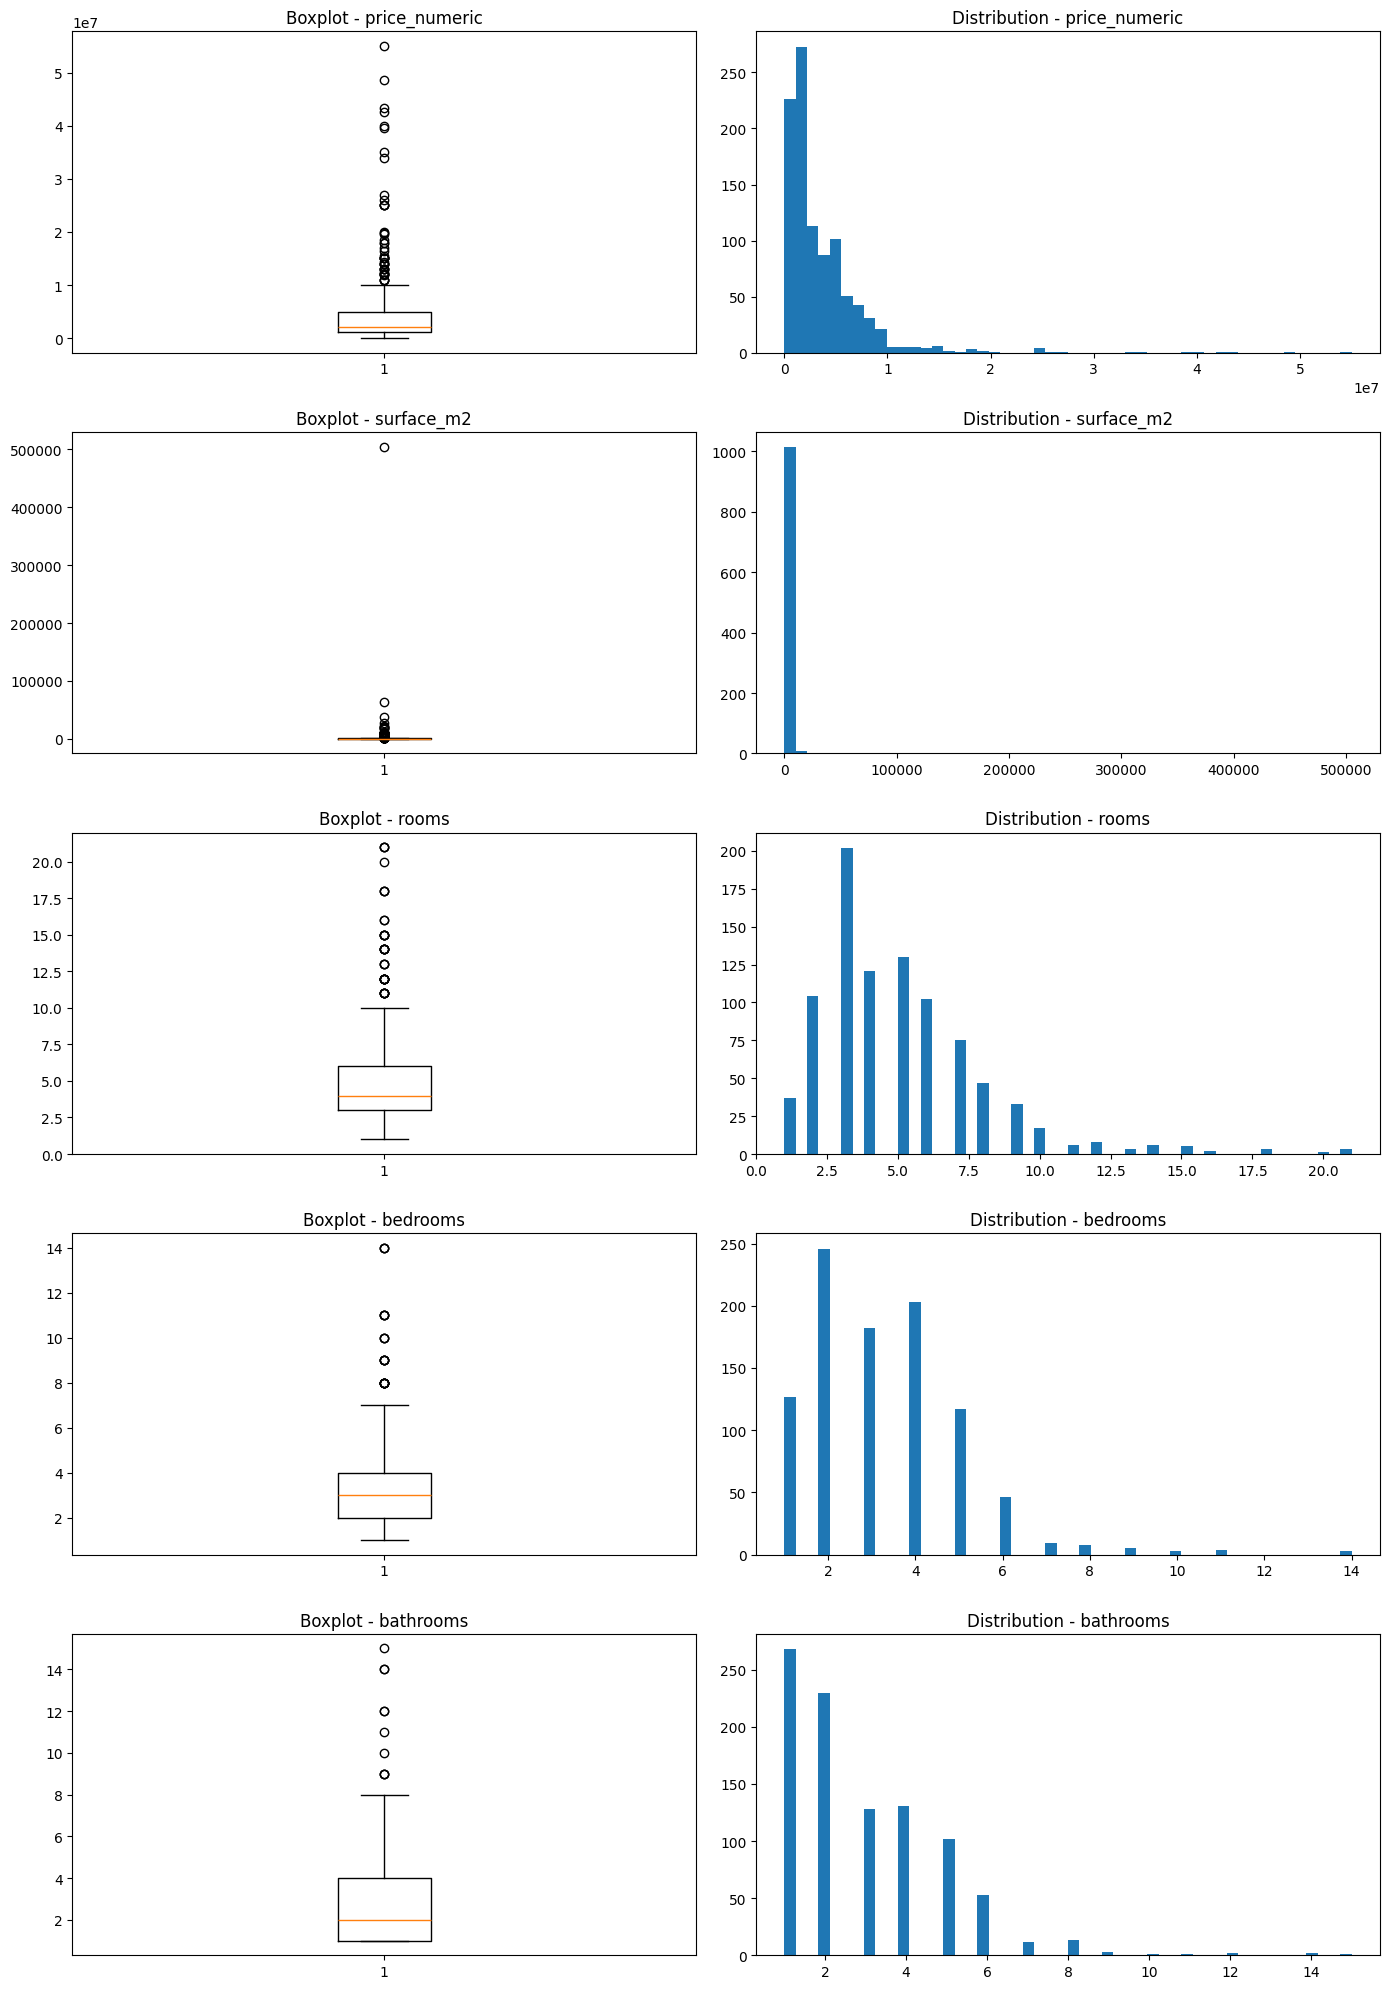

In [59]:
cols = ["price_numeric", "surface_m2", "rooms", "bedrooms", "bathrooms"]

fig, axes = plt.subplots(len(cols), 2, figsize=(14, 4*len(cols)))

for i, col in enumerate(cols):
    # Boxplot
    axes[i, 0].boxplot(df[col].dropna())
    axes[i, 0].set_title(f"Boxplot - {col}")
    
    # Histogram
    axes[i, 1].hist(df[col].dropna(), bins=50)
    axes[i, 1].set_title(f"Distribution - {col}")

plt.tight_layout()
plt.show()

In [60]:
for col in ["rooms", "bedrooms", "bathrooms"]:
    print(f"--- {col} ---")
    print(df[col].value_counts().sort_index())
    print()

--- rooms ---
rooms
1.0      37
2.0     104
3.0     202
4.0     121
5.0     130
6.0     102
7.0      75
8.0      47
9.0      33
10.0     17
11.0      6
12.0      8
13.0      3
14.0      6
15.0      5
16.0      2
18.0      3
20.0      1
21.0      3
Name: count, dtype: int64

--- bedrooms ---
bedrooms
1.0     127
2.0     246
3.0     182
4.0     203
5.0     117
6.0      46
7.0       9
8.0       8
9.0       5
10.0      3
11.0      4
14.0      3
Name: count, dtype: int64

--- bathrooms ---
bathrooms
1.0     268
2.0     230
3.0     128
4.0     131
5.0     102
6.0      53
7.0      12
8.0      13
9.0       3
10.0      1
11.0      1
12.0      2
14.0      2
15.0      1
Name: count, dtype: int64



In [61]:
for col, cap in [("rooms", 15), ("bedrooms", 12), ("bathrooms", 12)]:
    df[col] = df[col].clip(upper=cap)

df[["rooms", "bedrooms", "bathrooms"]].describe()

,rooms,bedrooms,bathrooms
count,905.000000,953.000000,947.000000
mean,4.928177,3.273872,2.914467
std,2.766010,1.756596,1.910821
min,1.000000,1.000000,1.000000
25%,3.000000,2.000000,1.000000
50%,4.000000,3.000000,2.000000
75%,6.000000,4.000000,4.000000
max,15.000000,12.000000,12.000000


In [62]:
print(df[["rooms", "bedrooms", "bathrooms"]].isna().sum())

rooms        127
bedrooms      79
bathrooms     85
dtype: int64


In [63]:
# AUCUNE suppression : les annonces sans prix ("Prix à consulter") restent dans df.
# Elles ne servent pas a l'entrainement (pas de label) mais on leur PREDIT un prix a la fin.
print("Annonces avec prix    :", df["price_numeric"].notna().sum())
print("Annonces sans prix    :", df["price_numeric"].isna().sum())
print(df.shape)

Annonces avec prix    : 994
Annonces sans prix    : 38
(1032, 16)


In [64]:
import plotly.express as px

cols_numeriques = ["price_numeric", "surface_m2", "rooms", "bedrooms", "bathrooms"]

corr_matrix = df[cols_numeriques].corr()

fig = px.imshow(
    corr_matrix,
    text_auto=".2f",  
    color_continuous_scale="RdBu_r", 
    zmin=-1,
    zmax=1,
    title="Matrice de corrélation (Interactive)",
)

fig.update_layout(width=700, height=600, template="plotly_white")

fig.show()

In [65]:
df["log_surface"] = np.log1p(df["surface_m2"])
df["log_price"] = np.log1p(df["price_numeric"])

print(df[["log_price", "log_surface"]].corr())

             log_price  log_surface
log_price     1.000000     0.525836
log_surface   0.525836     1.000000


# Conclusion — Data Cleaning

Cette étape nous a permis d’améliorer considérablement la qualité des données immobilières. Nous avons traité les doublons, les valeurs manquantes, les incohérences dans les prix, les informations liées aux surfaces et les différentes écritures des quartiers. Nous avons également identifié et traité les valeurs aberrantes afin d’obtenir une base de données plus propre, cohérente et adaptée aux étapes suivantes de l’analyse et de la modélisation.

<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">3- Preprocessing</h2>
</div>

## 1.features engineering

### Filtrage et extraction d'échantillons textuels liés à l'état et à l'âge

In [66]:
df[df["description"].str.contains("neuf|rénové|renove|ancien|état|construit en|ans", case=False, na=False)][["title", "description"]].head(3)

,title,description
2,Villa moderne Route d'Amizmiz,"*** Villa route d'Amizmiz 1200m² *** Route D'Amizmiz magnifique villa en parfait état de 1200m² avec un terrain de 2 hectare et une belle piscine. Le bâtiment principal comprend un grand double salon, un grand salon, une salle à manger, une salle de jeux, un salon TV, une chambre principale avec..."
5,Villa 5 suites et piscine avec charme magnifique,"Villa de charme 5 chambres avec piscine – Proche Oberoi Dans un environnement calme et verdoyant, à proximité de The Oberoi Marrakech, découvrez cette villa de caractère d’environ 500 m², édifiée sur un magnifique terrain arboré de 1 hectare. Entièrement de plain-pied, elle offre 5 chambres avec..."
6,Vente ou location Opportunité à saisir villa commerciale,"Découvrez cette magnifique propriété située dans le quartier prisé de Guéliz, à Marrakech. Avec une vaste surface construite de 780 m² s'étendant sur un terrain de 480 m², cette maison spacieuse offre un cadre de vie idéal en plein cœur de la ville. Son emplacement à Guéliz est stratégique, à pr..."


#### Analyse de l'état des biens immobiliers
#### Ce bloc de code permet d'analyser la fréquence des mots-clés liés à l'état physique ou juridique des biens immobiliers (par exemple : *neuf, rénové, bon état, titré*) dans la colonne `description` du dataset. 


In [67]:
mots_etat = ["neuf", "rénové", "renove", "à rénover", "a renover", "bon état", "excellent état", "refait à neuf", "vna", "titré"]

for mot in mots_etat:
    count = df["description"].str.contains(mot, case=False, na=False).sum()
    print(f"{mot}: {count}")

neuf: 44
rénové: 28
renove: 0
à rénover: 2
a renover: 0
bon état: 8
excellent état: 4
refait à neuf: 3
vna: 7
titré: 72


### Extraction d'exemples sur l'âge et la construction des biens
#### Ce bloc de code permet de filtrer et d'afficher un échantillon (les 5 premiers résultats) des descriptions d'annonces qui contiennent des informations précises sur la date ou l'âge de construction du bien (ex: *construit en*, *ans d'ancienneté*, *année de construction*). 


In [68]:
pd.set_option('display.max_colwidth', None)
exemples = df[df["description"].str.contains("construit en|ans d'ancienneté|année de construction", case=False, na=False)][["title", "description"]].head(5)
for idx, row in exemples.iterrows():
    print(row["title"])
    print(row["description"])
    print("---")

Villa d’exception sur golf
Sur 780 m2 et 650 de jouissance de terrain Piscine pierre de Bali Douche ext a débordement Terrasse Année de construction fin 2025 Arboré 550 m2 Alu du Maroc menuiseries double vitrage Douche ext Non mitoyenne Barbecue Puit Place de parking 1 Au RDC Lave main a l’entrée avec WC 3 salons Salle a manger Petit jardinet intérieur Niches de décoration Rideaux électrique Cuisine entièrement aménagée et équipée Laminâmes pour plan d...
---
Vend appartement à Guéliz. Surface de 84 m². Jardin et asc...
Situé dans le quartier prisé de Guéliz à Marrakech, cet appartement moderne de 84 m² offre un cadre de vie élégant et confortable. Avec une construction relativement récente, entre 1 et 5 ans d'ancienneté, il se trouve au deuxième étage d'un immeuble équipé d'un ascenseur, garantissant un accès facile et sécurisé. L'intérieur de l'appartement est caractérisé par un sol en carrelage qui confère une atmosphère fraîche et contemporaine aux espaces...
---


### Analyse de la fréquence des expressions liées à l'âge des biens
Ce bloc de code teste une liste élargie de mots-clés et d'expressions temporelles (tels que *ans d'ancienneté*, *année de construction*, ou simplement *ans*) pour quantifier leur présence dans les descriptions des annonces.

In [69]:
mots_age = ["construit en", "année de construction", "ans d'ancienneté", "bâti en", "date de construction", "ans", "neuf de"]

for mot in mots_age:
    count = df["description"].str.contains(mot, case=False, na=False).sum()
    print(f"{mot}: {count}")

construit en: 0
année de construction: 1
ans d'ancienneté: 1
bâti en: 0
date de construction: 0
ans: 541
neuf de: 14


## Extraction de l'état du bien
On classe chaque annonce selon des mots-clés trouvés dans title/description :
neuf, rénové, bon état, excellent état, à rénover (VNA).

In [70]:
import re

def extraire_etat(row):
    texte = f"{row['title']} {row['description']}".lower()
    
    if re.search(r"à rénover|a renover|vna\b", texte):
        return "à rénover"
    elif re.search(r"\bneuf\b|neuve\b|refait à neuf|refait a neuf", texte):
        return "neuf"
    elif re.search(r"bon état|bon etat|excellent état|excellent etat|rénové|renove", texte):
        return "bon état"
    else:
        return "non spécifié"

df["etat_bien"] = df.apply(extraire_etat, axis=1)

df["etat_bien"].value_counts()

etat_bien
non spécifié    884
neuf             90
bon état         33
à rénover        25
Name: count, dtype: int64

In [71]:
df[["price_numeric", "surface_m2", "rooms", "bedrooms", "bathrooms"]].isna().sum()

price_numeric     38
surface_m2         5
rooms            127
bedrooms          79
bathrooms         85
dtype: int64

### Extraction et regroupement de l'âge des biens immobiliers
1. **Extraction (`extraire_age`)** : Détecte les mentions textuelles de type *"moins de X ans"* ou *"entre X et Y ans"*.
2. **Regroupement (`regrouper_age`)** : Catégorise les intervalles extraits en tranches d'âge homogènes (`0-5 ans`, `5-10 ans`, `+10 ans`) pour faciliter l'analyse statistique et la modélisation ultérieure.
3. **Comptage final (`value_counts`)** : Affiche la répartition des biens selon leur tranche d'âge au sein du dataset.

In [72]:
def extraire_age(texte):
    texte = str(texte).lower()
    
    match = re.search(r"moins de\s*(\d+)\s*ans", texte)
    if match:
        return f"0-{match.group(1)} ans"
    
    match = re.search(r"(?:entre\s*)?(\d+)\s*(?:à|et)\s*(\d+)\s*ans", texte)
    if match:
        return f"{match.group(1)}-{match.group(2)} ans"
    
    return np.nan

df["age_bien"] = df["description"].apply(extraire_age)

def regrouper_age(age_str):
    if pd.isna(age_str):
        return np.nan
    match = re.search(r"(\d+)-(\d+)", age_str)
    if not match:
        return np.nan
    min_age, max_age = int(match.group(1)), int(match.group(2))
    if max_age <= 5:
        return "0-5 ans"
    elif max_age <= 10:
        return "5-10 ans"
    else:
        return "+10 ans"

df["age_bien"] = df["age_bien"].apply(regrouper_age)

df["age_bien"].value_counts()

age_bien
0-5 ans     21
5-10 ans    21
+10 ans      4
Name: count, dtype: int64

In [73]:
df["age_bien"].isna().sum()

np.int64(986)

## remplissage des nans

In [74]:
df["age_bien"] = df["age_bien"].fillna("inconnu")
df["age_bien"].value_counts()

age_bien
inconnu     986
0-5 ans      21
5-10 ans     21
+10 ans       4
Name: count, dtype: int64

In [75]:
df[["price_numeric", "surface_m2", "rooms", "bedrooms", "bathrooms"]].isna().sum()

price_numeric     38
surface_m2         5
rooms            127
bedrooms          79
bathrooms         85
dtype: int64

In [76]:
df.isna().sum()

title                  0
transaction_type       0
city                   0
quartier               0
price_raw              0
price_numeric         38
surface_raw           11
surface_m2             5
rooms                127
bedrooms              79
bathrooms             85
description            0
property_type          0
surface_text         275
surface_from_text    747
surface_clean          5
log_surface            5
log_price             38
etat_bien              0
age_bien               0
dtype: int64

In [77]:
df[["price_numeric", "surface_clean", "rooms", "bedrooms", "bathrooms"]].isna().sum()

price_numeric     38
surface_clean      5
rooms            127
bedrooms          79
bathrooms         85
dtype: int64

In [78]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

cols = ["price_numeric", "rooms", "bedrooms", "bathrooms"]

# Création d'une grille de subplots (4 lignes, 2 colonnes)
fig = make_subplots(
    rows=len(cols),
    cols=2,
    subplot_titles=[
        f"{col} - {'Boxplot' if j%2==0 else 'Distribution'}"
        for col in cols
        for j in range(2)
    ],
)

for i, col in enumerate(cols):
  # Nettoyage des données (suppression des valeurs manquantes)
  data_clean = df[col].dropna()

  # 1. Ajout du Boxplot (Colonne 1)
  fig.add_trace(
      go.Box(y=data_clean, name=col, boxpoints=False, showlegend=False),
      row=i + 1,
      col=1,
  )

  # 2. Ajout de l'Histogramme (Colonne 2)
  fig.add_trace(
      go.Histogram(x=data_clean, name=col, nbinsx=50, showlegend=False),
      row=i + 1,
      col=2,
  )

# Mise à jour de la mise en page globale
fig.update_layout(
    height=400 * len(cols),
    title_text=(
        "Analyse des distributions et valeurs aberrantes (Boxplots &"
        " Histogrammes)"
    ),
    template="plotly_white",
)

fig.show()

Prix (price_numeric) : Les distributions montrent une asymétrie marquée vers la droite (forte concentration de biens abordables avec de nombreux outliers ou valeurs extrêmes très élevées).   Pièces, Chambres et Salles de bains : Les graphiques révèlent une distribution centrée sur les petits et moyens biens (généralement 2 à 4 pièces/chambres), avec quelques valeurs aberrantes au-delà de 10. 

In [79]:
import numpy as np
import plotly.express as px

# Calcul dyal log1p dyal surface_m2 w t-nqiyd dyal les valeurs manquantes
surface_log = np.log1p(df["surface_m2"].dropna())

# Création dyal l-histogramme b Plotly Express
fig = px.histogram(
    x=surface_log,
    nbins=50,
    title="Distribution log(surface_m2) (Interactive)",
    labels={"x": "log1p(surface_m2)", "y": "Fréquence"},
)

fig.update_layout(
    width=800, height=500, template="plotly_white", showlegend=False
)

fig.show()

La distribution logarithmique de la surface (log(surface_m2)) présente une forme bimodale (deux pics distincts autour de 4,5 et 6), ce qui indique la présence de deux catégories principales de biens (par exemple, des appartements de petite/moyenne surface et de grandes villas ou propriétés).

In [80]:
df.columns

Index(['title', 'transaction_type', 'city', 'quartier', 'price_raw',
       'price_numeric', 'surface_raw', 'surface_m2', 'rooms', 'bedrooms',
       'bathrooms', 'description', 'property_type', 'surface_text',
       'surface_from_text', 'surface_clean', 'log_surface', 'log_price',
       'etat_bien', 'age_bien'],
      dtype='str')

## dataset final et correction des prix

In [81]:
# ===== Dataset final : les 9 colonnes demandees (+ Loc_Type derive) =====
df_model = pd.DataFrame({
    "Type":          df["property_type"],
    "Localisation":  df["quartier"],
    "Area":          df["surface_clean"],     # surface avec corrections manuelles
    "Rooms":         df["rooms"],
    "Bedrooms":      df["bedrooms"],
    "Bathrooms":     df["bathrooms"],
    "Current_state": df["etat_bien"],
    "Age":           df["age_bien"],
    "Price":         df["price_numeric"],
})

# valeurs impossibles -> "manquantes" (aucune ligne supprimee)
df_model.loc[df_model["Area"] < 15, "Area"] = np.nan

cat_cols = ["Type", "Localisation", "Current_state", "Age"]
df_model[cat_cols] = df_model[cat_cols].fillna("inconnu").astype(str)
df_model["Loc_Type"] = df_model["Localisation"] + "|" + df_model["Type"]

feat_cols = ["Type", "Localisation", "Area", "Rooms", "Bedrooms", "Bathrooms",
             "Current_state", "Age", "Loc_Type"]
labeled = df_model["Price"].notna()
X_all = df_model[feat_cols]

print(df_model["Type"].value_counts().to_dict())
print(df_model.shape, "| avec prix :", labeled.sum(), "| sans prix :", (~labeled).sum())
df_model.isna().sum()

{'Villa': 561, 'Appartement': 471}
(1032, 10) | avec prix : 994 | sans prix : 38


Type               0
Localisation       0
Area               5
Rooms            127
Bedrooms          79
Bathrooms         85
Current_state      0
Age                0
Price             38
Loc_Type           0
dtype: int64

In [82]:
import re, math
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, TargetEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 150)

## 4. Prétraitement, Définition des Modèles et Évaluation

Ce bloc prépare toute l'infrastructure de Machine Learning pour l'entraînement et l'évaluation des algorithmes :

* **Pipeline de prétraitement (`make_prep`)** : Imputation des valeurs manquantes, transformation logarithmique de la surface (`Area`), encodage des variables catégorielles (One-Hot et Target Encoding pour `Loc_Type`), avec option de mise à l'échelle (*StandardScaler*) pour Ridge.
* **Grilles d'hyperparamètres (`models_grids`)** : Configuration de 5 modèles de régression puissants (Ridge, Random Forest, Gradient Boosting, XGBoost et CatBoost) avec leurs grilles d'optimisation respectives.
* **Fonction d'évaluation (`evaluer`)** : Calcul des métriques de performance à la fois dans l'espace logarithmique (où le modèle s'entraîne) et dans l'espace réel des Dirhams ($R^2$, MAE, et médiane du MAPE pour éviter l'impact des valeurs extrêmes).

In [83]:
cat_ohe = ["Type", "Localisation", "Current_state", "Age"]
num_plain = ["Rooms", "Bedrooms", "Bathrooms"]

def make_prep(scale=False):
    imp = lambda: SimpleImputer(strategy="median", add_indicator=True)
    area_steps = [("imp", imp()), ("log", FunctionTransformer(np.log1p))]   # Area : imputation puis log
    plain_steps = [("imp", imp())]
    if scale:
        area_steps.append(("sc", StandardScaler()))
        plain_steps.append(("sc", StandardScaler()))
    return ColumnTransformer([
        ("area", Pipeline(area_steps), ["Area"]),
        ("num", Pipeline(plain_steps), num_plain),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=5, sparse_output=False), cat_ohe),
        ("te", TargetEncoder(target_type="continuous", smooth="auto", random_state=42), ["Loc_Type"]),
    ])

models_grids = {
    "Ridge": {
        "model": Pipeline([("prep", make_prep(scale=True)), ("m", Ridge())]),
        "params": {"m__alpha": [0.1, 1, 3, 10, 30]},
    },
    "Random Forest": {
        "model": Pipeline([("prep", make_prep()), ("m", RandomForestRegressor(random_state=42, n_jobs=-1))]),
        "params": {"m__n_estimators": [300, 600], "m__max_depth": [None, 12, 20],
                   "m__min_samples_leaf": [1, 2, 3], "m__max_features": [0.5, 0.8, 1.0]},
    },
    "Gradient Boosting": {
        "model": Pipeline([("prep", make_prep()), ("m", GradientBoostingRegressor(random_state=42))]),
        "params": {"m__n_estimators": [300, 600], "m__learning_rate": [0.03, 0.05, 0.1],
                   "m__max_depth": [3, 4, 5], "m__subsample": [0.7, 0.9, 1.0]},
    },
    "XGBoost": {
        "model": Pipeline([("prep", make_prep()), ("m", XGBRegressor(random_state=42, n_jobs=-1))]),
        "params": {"m__n_estimators": [300, 600], "m__learning_rate": [0.03, 0.05, 0.1],
                   "m__max_depth": [3, 4, 6], "m__subsample": [0.7, 0.9],
                   "m__colsample_bytree": [0.7, 0.9], "m__min_child_weight": [1, 3]},
    },
    "CatBoost": {
        "model": Pipeline([("prep", make_prep()), ("m", CatBoostRegressor(verbose=0, random_seed=42, allow_writing_files=False))]),
        "params": {"m__iterations": [500, 1000], "m__learning_rate": [0.03, 0.05, 0.1],
                   "m__depth": [4, 6, 8], "m__l2_leaf_reg": [1, 3, 5]},
    },
}

def evaluer(nom, model, Xtr, Xte, ytr, yte, extra=None):
    p_tr, p_te = model.predict(Xtr), model.predict(Xte)
    y_real, p_real = np.expm1(yte), np.expm1(p_te)
    row = {
        "Modèle": nom,
        "R2 Train (log)": round(r2_score(ytr, p_tr), 4),
        "R2 Test (log)":  round(r2_score(yte, p_te), 4),
        "R2 Test (DH)":   round(r2_score(y_real, p_real), 4),
        "MAE (DH)":       round(mean_absolute_error(y_real, p_real)),
        "MAPE median %":  round(float(np.median(np.abs(y_real - p_real) / y_real) * 100), 1),
    }
    if extra: row["Meilleurs paramètres"] = extra
    return row

## 3. Correction des prix (Euros vs Dirhams)

Ce bloc permet de détecter et de corriger automatiquement les annonces affichées par erreur en Dirhams (DH) alors que les prix réels sont en Euros (€) :

* **Méthode textuelle :** Recherche d'une mention explicite d'euros (`€`, `euros`, `eur`) dans le titre ou la description dont le montant correspond au prix affiché (à 10% près).
* **Méthode heuristique (ML) :** Utilisation d'un modèle de prédiction (Gradient Boosting) pour identifier les annonces suspectes dont le prix prédit est 4 à 20 fois supérieur au prix affiché, tout en respectant des seuils de prix au mètre carré plausibles.

In [84]:
# ===== Correction des prix : certaines annonces sont en EUROS mais affichees "DH" =====
EUR_RATE = 10.8                    # 1 EUR ~ 10.8 DH
CORRIGER_HEURISTIQUE = True        # False = on corrige seulement les annonces qui disent "euros" dans le texte

# 1) prix ecrit en euros dans le texte, egal (a 10% pres) au price_numeric
txt_all = (df["title"].fillna("") + " " + df["description"].fillna("")).str.lower()

def prix_euro_texte(t):
    m = re.search(r"(\d{1,3}(?:[\s.,]\d{3})+|\d{5,})\s*(?:€|euros?|eur\b)", t)
    if not m:
        return np.nan
    return float(re.sub(r"[\s.,]", "", m.group(1)))

df["eur_txt"] = txt_all.apply(prix_euro_texte)
df["is_eur"] = df["eur_txt"].notna() & (df["eur_txt"] / df["price_numeric"]).between(0.9, 1.1)
print("Annonces en euros (texte explicite) :", int(df["is_eur"].sum()))

# 2) annonces suspectes : prediction out-of-fold 4 a 20 fois plus grande que le prix affiche
X_l = X_all[labeled]
y_l = np.log1p(df_model.loc[labeled, "Price"])
baseline = Pipeline([("prep", make_prep()),
                     ("m", GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                     max_depth=4, subsample=0.8, random_state=42))])
oof = np.expm1(cross_val_predict(baseline, X_l, y_l, cv=KFold(5, shuffle=True, random_state=0)))

P = df_model.loc[labeled, "Price"]
ratio = pd.Series(oof, index=P.index) / P
pm2 = P * EUR_RATE / df_model.loc[labeled, "Area"]
plausible = np.where(df_model.loc[labeled, "Type"] == "Appartement",
                     pm2.between(8000, 45000) | pm2.isna(),
                     (P * EUR_RATE) < 20_000_000)
suspect = ratio.between(4, 20) & plausible

# 3) application (les lignes restent, le prix d'origine est conserve dans Price_orig)
df_model["Price_orig"] = df_model["Price"]
df_model["is_eur"] = df["is_eur"].reindex(df_model.index).fillna(False).astype(bool)
df_model["Price_corrige"] = df_model["is_eur"]
if CORRIGER_HEURISTIQUE:
    df_model.loc[suspect[suspect].index, "Price_corrige"] = True

df_model.loc[df_model["Price_corrige"], "Price"] = df_model.loc[df_model["Price_corrige"], "Price_orig"] * EUR_RATE
print("Prix corriges :", int(df_model["Price_corrige"].sum()), "sur", int(labeled.sum()),
      "| dont texte euro :", int(df_model["is_eur"].sum()))

# verif visuelle : regarde ces lignes !
df_model[df_model["Price_corrige"]][["Type", "Localisation", "Area", "Price_orig", "Price"]].head(15)

Annonces en euros (texte explicite) : 2


c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cros

Prix corriges : 70 sur 994 | dont texte euro : 2


,Type,Localisation,Area,Price_orig,Price
26,Villa,Autre / Centre,938.0,140000.0,1512000.0
27,Villa,Route de Fès,260.0,250000.0,2700000.0
28,Villa,Route de Fès,140.0,260000.0,2808000.0
29,Villa,Palmeraie,384.0,290000.0,3132000.0
30,Villa,Palmeraie,423.0,310000.0,3348000.0
31,Villa,Autre / Centre,264.0,320000.0,3456000.0
32,Villa,Palmeraie,453.0,330000.0,3564000.0
33,Villa,Route de Casablanca,266.0,350000.0,3780000.0
35,Villa,Route de Fès,720.0,375000.0,4050000.0
36,Villa,Amelkis,200.0,380000.0,4104000.0


### Nettoyage cible : terrains, euros, loyers, Vaneau

## 5. Nettoyage ciblé des prix et des types (Sans suppression de lignes)

Ce bloc affine la qualité des données en traitant les cas particuliers sans supprimer aucune ligne du dataset :

* **Détection des terrains :** Création d'un indicateur `Is_terrain` pour repérer les terrains (ex. annonces de "terrain nu", "constructible", etc.) et les exclure de l'entraînement.
* **Correction des appartements en Euros (règle du $Prix/m^2$) :** Conversion automatique en Dirhams des appartements dont le prix au mètre carré initial est anormalement bas mais devient tout à fait plausible après application du taux de change (x 10.8).
* **Gestion des prix suspects et aberrants :** Isolation des prix restants incohérents (via des seuils de $Prix/m^2$ pour les appartements et de prix minimal pour les villas), en passant leur prix à `NaN` pour les faire prédire par le modèle tout en conservant leur valeur d'origine dans `Price_orig`.
* **Préparation des variables finales :** Reconstruction de la variable croisée `Loc_Type` et définition du masque `labeled` pour séparer les données d'entraînement de celles à prédire.

In [85]:
# ===== Nettoyage cible des prix / types (AUCUNE ligne supprimee) =====

# (a) annonces de TERRAIN classees "Villa" -> flag Is_terrain (aucune ligne supprimee)
t_low = df["title"].fillna("").str.lower()
is_terrain = t_low.str.contains(
    r"^\s*(?:vente\s+(?:de\s+|d')?)?(?:beau\s+|grand\s+)?terrain\b|\bterrain\s+(?:nu|constructible|titr|agricole|en milkia|à bâtir|a batir|à vendre|a vendre)",
    regex=True).reindex(df_model.index).fillna(False)
df_model["Is_terrain"] = is_terrain      # Type reste Villa/Appartement ; ces annonces sont exclues de l'entrainement
print("Annonces de terrain (exclues de l'entrainement) :", int(is_terrain.sum()))
display(df.loc[is_terrain[is_terrain].index, "title"].str[:80].head(3))

# (b) appartements en euros SANS mention dans le texte : prix/m2 impossible en DH mais normal x 10.8
pm2 = df_model["Price"] / df_model["Area"]
apt = df_model["Type"].eq("Appartement") & df_model["Price"].notna() & ~df_model["Price_corrige"]
regle_eur = apt & (pm2 < 4500) & (pm2 * EUR_RATE).between(9000, 45000)
df_model.loc[regle_eur, "Price"] = df_model.loc[regle_eur, "Price"] * EUR_RATE
df_model.loc[regle_eur, "Price_corrige"] = True
print("Appartements corriges (regle prix/m2) :", int(regle_eur.sum()))

# (c) prix encore impossibles -> traites comme "Prix à consulter" (la ligne reste, on PREDIT son prix)
pm2 = df_model["Price"] / df_model["Area"]
apt_bad = df_model["Type"].eq("Appartement") & ((pm2 < 4500) | (pm2 > 45000))
villa_bad = df_model["Type"].eq("Villa") & ~df_model["Is_terrain"] & (df_model["Price"] < 300_000)
suspect_final = (apt_bad | villa_bad) & df_model["Price"].notna()
df_model["Price_suspect"] = suspect_final
print("Prix suspects mis en 'a predire' :", int(suspect_final.sum()))
display(df_model.loc[suspect_final, ["Type", "Localisation", "Area", "Price_orig"]].head(3))
df_model.loc[suspect_final, "Price"] = np.nan      # Price_orig garde la valeur d'origine

# (d) reconstruire les variables utilisees par le split
df_model["Loc_Type"] = df_model["Localisation"] + "|" + df_model["Type"]
labeled = df_model["Price"].notna() & ~df_model["Is_terrain"]
X_all = df_model[feat_cols]
print("Avec prix :", int(labeled.sum()), "| a predire :", int((~labeled).sum()), "| lignes totales :", len(df_model))


Annonces de terrain (exclues de l'entrainement) : 52


1                                     Terrain Pré autorisé GH2
4                          Terrain 1180m en 2 accès différents
18    Vente de terrain note pour agricole ou villa par hectare
Name: title, dtype: str

Appartements corriges (regle prix/m2) : 6
Prix suspects mis en 'a predire' : 13


,Type,Localisation,Area,Price_orig
22,Villa,Route de Tahanaout,257.0,26000.0
23,Villa,Autre / Centre,500.0,35000.0
24,Villa,Hivernage,719.0,42000.0


Avec prix : 933 | a predire : 99 | lignes totales : 1032


## 6. Correction spécifique des annonces "Vaneau Maroc"

Ce bloc gère un cas particulier lié à une agence immobilière spécifique :

* **Détection ciblée :** Repérage des annonces de l'agence *Vaneau Maroc* dont les prix au mètre carré affichés sont anormalement bas (souvent affichés en Euros au lieu des Dirhams).
* **Application du taux de change :** Conversion automatique en Dirhams de ces annonces pour les aligner sur le marché local, tout en mettant à jour les drapeaux de correction et de suspicion.
* **Vérification finale :** Recalcul du prix médian au mètre carré par type de bien pour s'assurer que les annonces de Vaneau corrigées retrouvent un niveau cohérent par rapport au reste du marché.

In [86]:
# ===== Agence Vaneau Maroc : prix/m2 ~6-8x plus bas que le reste -> prix en EUROS (hypothese) =====
desc_all = (df["title"].fillna("") + " " + df["description"].fillna("")).str.lower()
df["vaneau"] = desc_all.str.contains("vaneau")
print("Annonces Vaneau :", int(df["vaneau"].sum()))

CORRIGER_VANEAU = True
if CORRIGER_VANEAU:
    m = (df["vaneau"].reindex(df_model.index).fillna(False)
         & ~df_model["Price_corrige"]
         & df_model["Price_orig"].notna()
         & ~df_model["Is_terrain"])
    df_model.loc[m, "Price"] = df_model.loc[m, "Price_orig"] * EUR_RATE
    df_model.loc[m, "Price_corrige"] = True
    df_model.loc[m, "Price_suspect"] = False
    print("Vaneau corriges :", int(m.sum()))

labeled = df_model["Price"].notna() & ~df_model["Is_terrain"]
X_all = df_model[feat_cols]
print("Avec prix :", int(labeled.sum()), "| a predire :", int((~labeled).sum()), "| lignes totales :", len(df_model))

# verification : prix/m2 median (doit etre proche des autres annonces)
d = df_model.join(df["vaneau"])
d["pm2"] = d["Price"] / d["Area"]
d[~d["Is_terrain"]].groupby(["Type", "vaneau"])["pm2"].agg(["count", "median"]).round(0)

Annonces Vaneau : 20
Vaneau corriges : 12
Avec prix : 933 | a predire : 99 | lignes totales : 1032


count   median
Type        vaneau                
Appartement False     442  19047.0
            True        2  24741.0
Villa       False     468  12325.0
            True       16  20276.0

### Remplissage des valeurs manquantes (features)

In [87]:
# ===== Remplissage des valeurs manquantes (SANS utiliser le prix => pas de fuite) =====
cols_n = ["Rooms", "Bedrooms", "Bathrooms", "Area"]
print("NaN avant :", df_model[cols_n].isna().sum().to_dict())

# 1) extraction depuis le titre / la description
txt = (df["title"].fillna("") + " " + df["description"].fillna("")).str.lower()
patterns = {
    "Bedrooms":  r"(\d+)\s*(?:chambres?|chbres?|chs?\b|suites?|bedrooms?)",
    "Rooms":     r"(\d+)\s*(?:pi[eè]ces?|rooms?)",
    "Bathrooms": r"(\d+)\s*(?:salles?\s*(?:de\s*)?(?:bains?|d'eau)|sdb|bathrooms?)",
}
for col, pat in patterns.items():
    ext = pd.to_numeric(txt.str.extract(pat)[0], errors="coerce")
    df_model[col] = df_model[col].fillna(ext)

# 2) relation Rooms ~ Bedrooms (ecart median calcule sur les lignes completes)
diff = (df_model["Rooms"] - df_model["Bedrooms"]).median()
m = df_model["Rooms"].isna() & df_model["Bedrooms"].notna()
df_model.loc[m, "Rooms"] = df_model.loc[m, "Bedrooms"] + diff
m = df_model["Bedrooms"].isna() & df_model["Rooms"].notna()
df_model.loc[m, "Bedrooms"] = (df_model.loc[m, "Rooms"] - diff).clip(lower=1)

# 3) mediane du groupe le plus proche (Type+Localisation, puis Type, puis global)
df_model["Bathrooms"] = df_model["Bathrooms"].fillna(
    df_model.groupby(["Type", "Bedrooms"])["Bathrooms"].transform("median"))
for col in cols_n:
    df_model[col] = df_model[col].fillna(df_model.groupby(["Type", "Localisation"])[col].transform("median"))
    df_model[col] = df_model[col].fillna(df_model.groupby("Type")[col].transform("median"))
    df_model[col] = df_model[col].fillna(df_model[col].median())

# valeurs entieres et bornees
for col, cap in [("Rooms", 15), ("Bedrooms", 12), ("Bathrooms", 12)]:
    df_model[col] = df_model[col].round().clip(lower=1, upper=cap)

X_all = df_model[feat_cols]
print("NaN apres :", df_model[feat_cols].isna().sum().sum(), "(features) |",
      "Price NaN (a predire) :", int(df_model["Price"].isna().sum()))
df_model[cols_n].describe().round(1)

NaN avant : {'Rooms': 127, 'Bedrooms': 79, 'Bathrooms': 85, 'Area': 5}
NaN apres : 0 (features) | Price NaN (a predire) : 51


,Rooms,Bedrooms,Bathrooms,Area
count,1032.0,1032.0,1032.0,1032.0
mean,4.9,3.3,3.0,1401.3
std,2.7,1.7,1.9,16079.9
min,1.0,1.0,1.0,27.0
25%,3.0,2.0,1.0,83.0
50%,5.0,3.0,3.0,236.0
75%,6.0,4.0,4.0,500.0
max,15.0,12.0,12.0,504870.0


### Current_state et Age : plus de valeurs 'inconnu'

In [88]:
# ===== Remplacer "non spécifié" / "inconnu" par de vraies categories =====
from datetime import datetime
ANNEE = datetime.now().year
txt = (df["title"].fillna("") + " " + df["description"].fillna("")).str.lower().reindex(df_model.index)
print("Avant :", df_model["Current_state"].value_counts().to_dict(), df_model["Age"].value_counts().to_dict())

# --- 1) Current_state : plus de mots-cles (l'ordre compte : "à rénover" avant "rénové")
etat_rules = [
    ("à rénover", r"à rénover|a renover|à rafra[iî]chir|travaux à pr[ée]voir|vna\b"),
    ("neuf",      r"\bneuf\b|neuve\b|jamais habit|nouvelle construction|programme neuf|livraison|cl[ée]s en main"),
    ("bon état",  r"bon [ée]tat|excellent [ée]tat|parfait [ée]tat|r[ée]nov[ée]|refait|bien entretenu|habitable|impeccable|r[ée]cent"),
]
m = df_model["Current_state"].eq("non spécifié")
for label, pat in etat_rules:
    hit = m & txt.str.contains(pat, regex=True)
    df_model.loc[hit, "Current_state"] = label
    m = m & ~hit

# --- 2) Age : annee de construction, puis coherence avec l'etat
def age_depuis_annee(t):
    r = re.search(r"(?:construit[e]?|construction|b[âa]ti[e]?|ann[ée]e)\s*(?:de\s*construction\s*)?(?:en|de|:)?\s*((?:19|20)\d{2})", t)
    return ANNEE - int(r.group(1)) if r else np.nan

def bucket(a):
    if pd.isna(a): return np.nan
    return "0-5 ans" if a <= 5 else ("5-10 ans" if a <= 10 else "+10 ans")

m = df_model["Age"].eq("inconnu")
df_model.loc[m, "Age"] = txt[m].apply(age_depuis_annee).apply(bucket).fillna("inconnu")

m = df_model["Age"].eq("inconnu")
df_model.loc[m & df_model["Current_state"].eq("neuf"), "Age"] = "0-5 ans"
df_model.loc[m & df_model["Current_state"].eq("à rénover"), "Age"] = "+10 ans"
df_model.loc[m & txt.str.contains(r"\bancien(?:ne)?\b|vieille", regex=True), "Age"] = "+10 ans"

# --- 3) le reste : valeur neutre ("bon état" / "+10 ans"). Le mode du groupe serait biaise :
#        les vendeurs ecrivent "neuf" quand c'est neuf, donc les annonces silencieuses sont plutot anciennes
STRATEGIE = "constante"    # "constante" (conseille) ou "groupe" (mode du Type+Localisation)

def remplir_mode(col, bad, defaut):
    miss = df_model[col].eq(bad)
    if STRATEGIE == "constante":
        df_model.loc[miss, col] = defaut; return
    known = df_model[~miss]
    if known.empty:
        print(f"  (!) {col}: aucune valeur connue -> '{defaut}' partout"); df_model.loc[miss, col] = defaut; return
    mode = lambda s: s.mode().iloc[0]
    g1 = known.groupby(["Type", "Localisation"])[col].agg(mode)
    g2 = known.groupby("Type")[col].agg(mode)
    glob = mode(known[col])
    for i in df_model.index[miss]:
        t, l = df_model.at[i, "Type"], df_model.at[i, "Localisation"]
        df_model.at[i, col] = g1.get((t, l), g2.get(t, glob))

remplir_mode("Current_state", "non spécifié", "bon état")
remplir_mode("Age", "inconnu", "+10 ans")

assert not df_model[["Current_state", "Age"]].isin(["non spécifié", "inconnu"]).any().any()
X_all = df_model[feat_cols]

print("Apres :", df_model["Current_state"].value_counts().to_dict(), df_model["Age"].value_counts().to_dict())


Avant : {'non spécifié': 884, 'neuf': 90, 'bon état': 33, 'à rénover': 25} {'inconnu': 986, '0-5 ans': 21, '5-10 ans': 21, '+10 ans': 4}
Apres : {'bon état': 862, 'neuf': 144, 'à rénover': 26} {'+10 ans': 845, '0-5 ans': 165, '5-10 ans': 22}


## 7. Exportation finale et préparation du fichier CSV propre

Ce dernier bloc finalise le pipeline de traitement des données immobilières :

* **Assemblage final :** Constitution du DataFrame final (`df_csv`) combinant les caractéristiques descriptives et le prix final retenu (mélange des prix réels, corrigés et prédits par le modèle).
* **Imputation de secours :** Comblement des éventuelles valeurs manquantes restantes sur les prix en se basant sur la médiane par type et localisation, avec un repli sur la médiane globale pour garantir l'absence de valeurs nulles (`NaN`).
* **Formatage et typage :** Conversion des variables numériques (pièces, chambres, salles de bains, surface et prix) en nombres entiers propres et arrondis.
* **Exportation :** Sauvegarde des données nettoyées dans le fichier `marrakech_clean.csv` avec un encodage compatible (UTF-8 avec BOM) pour une lecture optimale, suivie d'une vérification de la forme et du nombre de valeurs nulles.

In [89]:
final_cols = ["Type", "Localisation", "Area", "Rooms", "Bedrooms", "Bathrooms", "Current_state", "Age"]

df_csv = df_model[final_cols].copy()
df_csv["Price"] = df_model["Price"]   # prix reel (corrige si euro) ou prix predit

# terrains sans prix : mediane du groupe, pour ne laisser aucune valeur nulle
df_csv["Price"] = df_csv["Price"].fillna(df_csv.groupby(["Type", "Localisation"])["Price"].transform("median"))
df_csv["Price"] = df_csv["Price"].fillna(df_csv["Price"].median())

# entiers propres
for c in ["Rooms", "Bedrooms", "Bathrooms"]:
    df_csv[c] = df_csv[c].astype(int)
df_csv["Area"] = df_csv["Area"].round(0).astype(int)
df_csv["Price"] = df_csv["Price"].round(0).astype(int)

# sauvegarde
import os
df_csv.to_csv("marrakech_clean.csv", index=False, encoding="utf-8-sig")

print("Fichier :", os.path.abspath("marrakech_clean.csv"))
print(df_csv.shape, "| valeurs nulles :", int(df_csv.isna().sum().sum()))
df_csv.head()

Fichier : c:\Users\Pc\Desktop\MaisonDeLUX\ml\notebooks\marrakech\marrakech_clean.csv
(1032, 9) | valeurs nulles : 0


,Type,Localisation,Area,Rooms,Bedrooms,Bathrooms,Current_state,Age,Price
0,Villa,Autre / Centre,340,6,4,4,neuf,0-5 ans,6156000
1,Villa,Route de l'Ourika,26724,6,4,4,bon état,+10 ans,4850000
2,Villa,Route d'Amizmiz,20000,14,9,8,bon état,+10 ans,4900000
3,Villa,Route de l'Ourika,20000,9,6,7,bon état,+10 ans,4850000
4,Villa,Targa,1177,6,4,4,bon état,+10 ans,4950000


## 8. Division des données (Train/Test) et Winsorisation de la cible

Ce bloc prépare les jeux de données pour l'apprentissage automatique :

* **Séparation et transformation :** Sélection des lignes labellisées et application d'une transformation logarithmique (`np.log1p`) sur la cible (`Price`) pour normaliser sa distribution.
* **Partitionnement (Train/Test) :** Division des données en un ensemble d'entraînement (80%) et un ensemble de test (20%) via `train_test_split`.
* **Winsorisation (Clipping) :** Écrêtage des valeurs extrêmes de la cible sur l'ensemble d'entraînement entre les percentiles 1% et 99% (`quantile([0.01, 0.99])`) pour limiter l'impact des valeurs aberrantes sans supprimer aucune ligne du dataset.

In [90]:
# ===== Split (avec les prix corriges) =====
X = X_all[labeled]
y = np.log1p(df_model.loc[labeled, "Price"])      # TARGET EN LOG

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Winsorisation de la target d'entrainement (on CLIPPE, on ne supprime rien)
lo, hi = y_train.quantile([0.01, 0.99])
y_train_w = y_train.clip(lo, hi)
print(X_train.shape, X_test.shape)

(746, 9) (187, 9)


# Conclusion — Preprocessing

Le preprocessing a permis de préparer les données pour l’apprentissage automatique. Les variables numériques et catégorielles ont été traitées avec des méthodes adaptées, notamment l’imputation, les transformations numériques et l’encodage des variables catégorielles. La mise en place d’un pipeline garantit que les mêmes transformations sont appliquées de manière cohérente lors de l’entraînement et lors des futures prédictions.

<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">4- Modélisation</h2>
</div>

In [91]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results, best_models = [], {}

for name, cfg in models_grids.items():
    print(f"⏳ {name} ...")
    search = RandomizedSearchCV(cfg["model"], cfg["params"], n_iter=15, cv=kf,
                                scoring="r2", n_jobs=-1, random_state=42)
    search.fit(X_train, y_train_w)                    # entraine sur y winsorise
    best_models[name] = search.best_estimator_
    results.append(evaluer(name, search.best_estimator_, X_train, X_test, y_train, y_test,
                           str(search.best_params_)))   # evalue sur les VRAIS prix

tableau = pd.DataFrame(results).sort_values("R2 Test (log)", ascending=False).reset_index(drop=True)
tableau

⏳ Ridge ...


c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 5 is smaller than n_iter=15. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


⏳ Random Forest ...


c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


⏳ Gradient Boosting ...


...

⏳ XGBoost ...


c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


⏳ CatBoost ...


c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


,Modèle,R2 Train (log),R2 Test (log),R2 Test (DH),MAE (DH),MAPE median %,Meilleurs paramètres
0,Random Forest,0.8251,0.7271,0.5663,1418969,16.8,"{'m__n_estimators': 600, 'm__min_samples_leaf': 3, 'm__max_features': 0.5, 'm__max_depth': None}"
1,XGBoost,0.8358,0.7202,0.3312,1609940,19.2,"{'m__subsample': 0.9, 'm__n_estimators': 300, 'm__min_child_weight': 1, 'm__max_depth': 3, 'm__learning_rate': 0.05, 'm__colsample_bytree': 0.9}"
2,Ridge,0.7148,0.7056,0.5012,1479454,18.6,{'m__alpha': 3}
3,Gradient Boosting,0.8501,0.7043,0.1832,1716599,18.8,"{'m__subsample': 1.0, 'm__n_estimators': 300, 'm__max_depth': 4, 'm__learning_rate': 0.03}"
4,CatBoost,0.7866,0.6995,0.4957,1548890,19.3,"{'m__learning_rate': 0.03, 'm__l2_leaf_reg': 5, 'm__iterations': 500, 'm__depth': 4}"


In [92]:
def estimateur_stack(nom):
    est = clone(best_models[nom])            # copie non entrainee, memes hyperparametres
    if nom == "CatBoost":                    # bug d'encodage Windows (chemin avec accent)
        est.set_params(m__allow_writing_files=False)
    return est

top3 = tableau["Modèle"].head(3).tolist()
stack = StackingRegressor(
    estimators=[(n, estimateur_stack(n)) for n in top3],
    final_estimator=Ridge(alpha=1.0), cv=5, n_jobs=1
)
stack.fit(X_train, y_train_w)

final = pd.DataFrame([evaluer("Stacking " + "+".join(top3), stack, X_train, X_test, y_train, y_test)])
final

c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cros

,Modèle,R2 Train (log),R2 Test (log),R2 Test (DH),MAE (DH),MAPE median %
0,Stacking Random Forest+XGBoost+Ridge,0.7907,0.7276,0.5822,1408655,17.7


In [93]:
# R2 en cross-validation sur toutes les annonces avec prix (plus fiable qu'un seul split)
best_name = tableau.loc[0, "Modèle"]
cv_scores = cross_val_score(best_models[best_name], X, y, cv=KFold(5, shuffle=True, random_state=0), scoring="r2")
print(f"{best_name} | R2 CV (log) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cros

Random Forest | R2 CV (log) : 0.705 ± 0.035


In [94]:
# ===== Prediction des annonces SANS prix (aucune ligne supprimee) =====
modele_final = stack
modele_final.fit(X, y.clip(lo, hi))               # re-entraine sur toutes les annonces avec prix

df_model["Price_pred"] = np.expm1(modele_final.predict(X_all)).round(-3)
df_model.loc[df_model["Is_terrain"], "Price_pred"] = np.nan   # pas de prediction pour les terrains
df_model["Price_final"] = df_model["Price"].fillna(df_model["Price_pred"])

print(df_model.shape, "| NaN Price_final :", df_model["Price_final"].isna().sum())
df_model.loc[~labeled, ["Type", "Localisation", "Area", "Bedrooms", "Price_pred"]].head(10)

c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cros

(1032, 17) | NaN Price_final : 4


,Type,Localisation,Area,Bedrooms,Price_pred
0,Villa,Autre / Centre,340.0,4.0,4472000.0
1,Villa,Route de l'Ourika,26724.0,4.0,NaN
2,Villa,Route d'Amizmiz,20000.0,9.0,25199000.0
3,Villa,Route de l'Ourika,20000.0,6.0,15358000.0
4,Villa,Targa,1177.0,4.0,NaN
5,Villa,Autre / Centre,500.0,5.0,5817000.0
6,Villa,Guéliz,20000.0,1.0,8271000.0
7,Villa,Amelkis,1200.0,8.0,10536000.0
8,Villa,Route de Tahanaout,1000.0,8.0,7776000.0
9,Villa,Autre / Centre,424.0,5.0,5614000.0


### Diagnostic

In [96]:
# ===== Diagnostic des erreurs (sur le jeu de test) =====
best = best_models[best_name]
res = X_test.copy()
res["prix_reel"] = np.expm1(y_test)
res["prix_pred"] = np.expm1(best.predict(X_test))
res["err_%"] = ((res["prix_pred"] / res["prix_reel"] - 1) * 100).round(0)

for t, g in res.groupby("Type"):
    print(t, len(g), "R2 log:", round(r2_score(np.log1p(g["prix_reel"]), np.log1p(g["prix_pred"])), 3))
d = df_model[labeled].copy()
d["prix_m2"] = d["Price"] / d["Area"]
display(d.groupby("Type")["prix_m2"].describe(percentiles=[.01, .05, .5, .95, .99]).round(0))

top = res.reindex(res["err_%"].abs().sort_values(ascending=False).index).head(20)
top = top.join(df_model[["Price_orig", "Price_corrige"]])
top["prix_m2"] = (top["prix_reel"] / top["Area"]).round(0)
top["title"] = df.loc[top.index, "title"].str[:70]
top[["Type", "Localisation", "Area", "Bedrooms", "Price_orig", "Price_corrige",
     "prix_reel", "prix_pred", "err_%", "prix_m2", "title"]]

Appartement 88 R2 log: 0.676
Villa 99 R2 log: 0.205


,count,mean,std,min,1%,5%,50%,95%,99%,max
Type,,,,,,,,,,
Appartement,446.0,19177.0,6863.0,4554.0,6492.0,8000.0,19093.0,31053.0,37356.0,43200.0
Villa,487.0,13273.0,8200.0,79.0,353.0,1618.0,12500.0,28015.0,38725.0,62500.0


,Type,Localisation,Area,Bedrooms,Price_orig,Price_corrige,prix_reel,prix_pred,err_%,prix_m2,title
57,Villa,Route de l'Ourika,460.0,8.0,650000.0,False,650000.0,1.059802e+07,1530.0,1413.0,"Villa avec VNA route de l'Ourika, vue Atlas"
65,Villa,Palmeraie,570.0,4.0,830000.0,False,830000.0,4.458083e+06,437.0,1456.0,Villa Deluxe Premium 4 suites & piscine privée VNA
105,Villa,Autre / Centre,4200.0,2.0,1500000.0,False,1500000.0,6.630352e+06,342.0,357.0,Ferme avec Villa Plain Pied à Vendre à Ghmat – Route de L’Ou...
116,Villa,Amelkis,600.0,6.0,1750000.0,False,1750000.0,7.013503e+06,301.0,2917.0,Villa de Luxe avec 6 Suites sur le Golf d'Amelkis
611,Appartement,Autre / Centre,78.0,2.0,380000.0,False,380000.0,1.504894e+06,296.0,4872.0,Appartement à vendre
97,Villa,Autre / Centre,450.0,4.0,1350000.0,False,1350000.0,5.025867e+06,272.0,3000.0,"Propriété de charme avec VNA – Villa de standing sur 1,1 hec..."
615,Appartement,Autre / Centre,57.0,2.0,400000.0,False,400000.0,1.133225e+06,183.0,7018.0,Appartement rez-de-chaussée Doha portes de Marrakech
119,Villa,Autre / Centre,520.0,4.0,1800000.0,False,1800000.0,4.998569e+06,178.0,3462.0,Lot terrain villa plain pied 520m2
158,Villa,Route d'Amizmiz,560.0,8.0,2500000.0,False,2500000.0,6.772818e+06,171.0,4464.0,Vente villa de luxe à Route Amizmiz. Surface de 560 m². Meub...
648,Appartement,Guéliz,80.0,3.0,600000.0,False,600000.0,1.528889e+06,155.0,7500.0,"Appartement à vendre 15 minutes guéliz, les portes de Marrak..."


### Verification finale : aucune valeur manquante

In [97]:
final_cols = ["Type", "Localisation", "Area", "Rooms", "Bedrooms", "Bathrooms", "Current_state", "Age"]
df_out = df_model[final_cols + ["Price_final"]].rename(columns={"Price_final": "Price"})
print(df_out.isna().sum())
df_out.head()

Type             0
Localisation     0
Area             0
Rooms            0
Bedrooms         0
Bathrooms        0
Current_state    0
Age              0
Price            4
dtype: int64


,Type,Localisation,Area,Rooms,Bedrooms,Bathrooms,Current_state,Age,Price
0,Villa,Autre / Centre,340.0,6.0,4.0,4.0,neuf,0-5 ans,4472000.0
1,Villa,Route de l'Ourika,26724.0,6.0,4.0,4.0,bon état,+10 ans,NaN
2,Villa,Route d'Amizmiz,20000.0,14.0,9.0,8.0,bon état,+10 ans,25199000.0
3,Villa,Route de l'Ourika,20000.0,9.0,6.0,7.0,bon état,+10 ans,15358000.0
4,Villa,Targa,1177.0,6.0,4.0,4.0,bon état,+10 ans,NaN


In [98]:
df_out["Type"].value_counts()

Type
Villa          561
Appartement    471
Name: count, dtype: int64

In [99]:
df_out["Localisation"].value_counts()

Localisation
Autre / Centre         226
Guéliz                 216
Route de l'Ourika      101
Palmeraie               65
Targa                   64
Route d'Amizmiz         60
Route de Tahanaout      50
Route de Casablanca     45
M'hamid                 34
Route de Fès            33
Hivernage               27
Amelkis                 24
Prestigia               21
Agdal                   18
Route de Safi           16
Chrifia                 14
Ménara                  12
Médina                   6
Name: count, dtype: int64

In [100]:
df_out["Age"].value_counts()

Age
+10 ans     845
0-5 ans     165
5-10 ans     22
Name: count, dtype: int64

# Conclusion — Prédiction finale

Après avoir sélectionné et évalué le meilleur modèle, nous pouvons l’utiliser pour estimer les prix des biens immobiliers ne disposant pas d’un prix exploitable. Cette étape permet de passer d’une analyse descriptive à une application concrète de Machine Learning, en utilisant les caractéristiques disponibles du bien pour produire une estimation de son prix.

In [ ]:

import joblib
import json
import numpy as np


scores = tableau[["Modèle", "R2 Test (log)", "R2 Test (DH)", "MAE (DH)", "MAPE median %"]].copy()

stack_r2_log = float(final["R2 Test (log)"].iloc[0])
stack_r2_dh = float(final["R2 Test (DH)"].iloc[0])
stack_mae = float(final["MAE (DH)"].iloc[0])
stack_mape = float(final["MAPE median %"].iloc[0])

stack_result = pd.DataFrame([{
    "Modèle": "Stacking",
    "R2 Test (log)": stack_r2_log,
    "R2 Test (DH)": stack_r2_dh,
    "MAE (DH)": stack_mae,
    "MAPE median %": stack_mape
}])

# Tous les modèles
all_scores = pd.concat(
    [scores, stack_result],
    ignore_index=True
)


best_row = all_scores.loc[
    all_scores["R2 Test (log)"].idxmax()
]

best_name = best_row["Modèle"]

# Sélection du modèle correspondant
if best_name == "Stacking":
    best_model = stack
else:
    best_model = best_models[best_name]


model_path = "best_model_marrakech.pkl"

joblib.dump(
    best_model,
    model_path
)



metadata = {
    "project": "Prediction des prix immobiliers - Marrakech",

    "model_name": str(best_name),

    "metrics": {
        "R2_Test_log": float(best_row["R2 Test (log)"]),
        "R2_Test_DH": float(best_row["R2 Test (DH)"]),
        "MAE_DH": float(best_row["MAE (DH)"]),
        "MAPE_median_percent": float(best_row["MAPE median %"])
    },

    "target": "Price",

    "target_transformation": "log1p",

    "prediction_inverse_transformation": "expm1",

    "features": feat_cols,

    "categorical_features": [
        "Type",
        "Localisation",
        "Current_state",
        "Age",
        "Loc_Type"
    ],

    "numerical_features": [
        "Area",
        "Rooms",
        "Bedrooms",
        "Bathrooms"
    ],

    "test_size": 0.20,

    "random_state": 42,

    "cross_validation": 5,

    "price_unit": "DH"
}

# Ajouter les hyperparamètres si modèle individuel
if best_name != "Stacking":

    metadata["best_parameters"] = {
        str(k): (
            v.item() if isinstance(v, np.generic)
            else v
        )
        for k, v in best_models[best_name].get_params().items()
        if k.startswith("m__")
    }



json_path = "best_model_marrakech.json"

with open(
    json_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        ensure_ascii=False,
        indent=4
    )



print("=" * 60)
print("           MEILLEUR MODÈLE SAUVEGARDÉ")
print("=" * 60)

print(f"Modèle       : {best_name}")
print(f"R² Test log  : {best_row['R2 Test (log)']:.4f}")
print(f"R² Test DH   : {best_row['R2 Test (DH)']:.4f}")
print(f"MAE          : {best_row['MAE (DH)']:,.0f} DH")
print(f"MAPE médian  : {best_row['MAPE median %']:.1f} %")

print("\nFichiers créés :")
print(f"✓ {model_path}")
print(f"✓ {json_path}")

           MEILLEUR MODÈLE SAUVEGARDÉ
Modèle       : Stacking
R² Test log  : 0.7276
R² Test DH   : 0.5822
MAE          : 1,408,655 DH
MAPE médian  : 17.7 %

Fichiers créés :
✓ best_model_marrakech.pkl
✓ best_model_marrakech.json
